# CipherMind Sentinel — Model Training & Evaluation

**UNSW-NB15 network-intrusion detection · Master ML notebook**

This notebook is the canonical, reproducible record of every machine-learning
decision behind CipherMind Sentinel: dataset validation, exploratory analysis,
leakage control, feature engineering, model comparison, training of the layered
detection architecture (binary detector → multiclass attack classifier →
unsupervised anomaly detector → transparent risk scoring), probability
calibration, one-shot evaluation on the official test set, SHAP
explainability, error/rare-class analysis, and artifact export for the
production inference engine.

## How to run

| Mode | What it does | Runtime |
|---|---|---|
| `MODE = "train"` | Complete pipeline from raw CSVs to exported model artifacts (`ml/artifacts/**`). Deterministic (seed 42). | ~30–60 min on 2 CPU cores |
| `MODE = "verify"` *(default)* | Loads the shipped trained models (`ml/artifacts/models/*.txt`), re-fits the preprocessing pipeline, re-runs the full official-test evaluation, and **asserts that every metric reproduces the shipped artifacts**. Read-only for production artifacts (writes only `ml/artifacts/reports/notebook_verification.json`). | ~3–6 min |

Set `MODE` in the configuration cell below. Both modes run top-to-bottom with
no hidden steps: every cell either computes a value or loads a shipped
artifact, and all downstream cells depend only on upstream cells.

**Verified release metrics (official UNSW-NB15 test set, reproduced in §19):**

| Model | Metric | Value |
|---|---|---|
| A — Binary attack detector (LightGBM, calibrated) | F1 / ROC-AUC / PR-AUC | **0.8902 / 0.9826 / 0.9873** |
| B — Multiclass attack-category classifier | macro-F1 / weighted-F1 | **0.5197 / 0.7856** |
| C — Isolation-Forest anomaly detector | ROC-AUC / precision@1000 | **0.7963 / 0.981** |

**Environment:** Python 3.12 · numpy 2.1 · pandas 2.2 · scikit-learn 1.5 ·
LightGBM 4.5 · XGBoost 2.1 · shap 0.52 · matplotlib 3.9 (see `requirements.txt`).

**Dataset:** UNSW-NB15 training/testing sets (175,341 / 82,332 flow records,
45 columns). Moustafa, N. & Slay, J. (2015), *"UNSW-NB15: a comprehensive data
set for network intrusion detection systems"* — as supplied with the
CipherMind AI '26 challenge. **Honesty note:** the supplied CSVs contain *no*
source/destination IPs, ports, user ids, device ids, or timestamps; no such
fields are fabricated anywhere in this project (see §04 and §08).

*Generated: 2026-08-30 · CipherMind Sentinel v1.0.0*


## 01 — Project Overview

**The problem.** A SOC (Security Operations Center) drowns in alerts. CipherMind
Sentinel replaces a wall of raw alerts with a small number of *risk-scored,
explained, correlated incidents*. The ML core is a **layered detection
architecture** — each layer answers a different operational question and fails
independently:

| Layer | Model | Question it answers | Algorithm |
|---|---|---|---|
| **A** | Binary attack detector | *Is this flow an attack?* | LightGBM, Platt-calibrated, F1-optimal threshold |
| **B** | Multiclass classifier | *Which attack category?* | LightGBM (class-balanced), temperature-scaled |
| **C** | Anomaly detector | *Is this behaviour unusual even if no label says so?* | Isolation Forest trained on **normal traffic only** |
| **D** | Transparent risk score | *How urgent is this event right now?* | Documented weighted formula over A/B/C outputs (no learned fake labels) |

**Why layering?** Layer A gives a high-recall first filter with an honest,
calibrated probability. Layer B adds tactical context but is honest about its
weakness on rare classes (macro-F1 ≈ 0.52 on 10 heavily-imbalanced classes —
see §22). Layer C is deliberately *unsupervised*: it can flag novel behaviour
that no label in the training set covers, and its disagreement with Layer A is
itself an informative signal. Layer D is **not** a model: every point of risk
is traceable to a documented weight (`ml/artifacts/metadata/model_registry.json`),
so an analyst can audit why an event scored 74 and not 40.

**Methodological commitments** (enforced in code throughout this notebook):

1. **Leakage control is non-negotiable** — preprocessors, model selection,
   calibration and thresholds are fitted on the *training split only*; the
   official test set is scored **exactly once** (§19).
2. **Calibrated probabilities** — raw LightGBM scores are not probabilities;
   Platt scaling (binary) and temperature scaling (multiclass) are fitted on
   5-fold out-of-fold train predictions (§18).
3. **Explainability built-in** — global TreeSHAP importance (§20) and exact
   local attributions are first-class artifacts consumed by the SOC UI.
4. **Honest limitations** — per-class weakness, FPR at the chosen threshold,
   and dataset gaps are reported as results, not footnotes (§21, §22).

The trained artifacts feed a production **TypeScript inference engine** (Bun
mini-service) that re-implements the LightGBM tree walk, Isolation-Forest
scoring and Saabas attributions exactly; it was cross-validated against this
Python pipeline (10/10 rows, probability match ≤ 1e-4). The application
**never retrains at runtime** — it loads the JSON artifacts exported in §24.


## 02 — Imports & Environment

All dependencies are standard scientific-Python packages pinned in
`requirements.txt`. Determinism: every stochastic component (LightGBM,
RandomForest, XGBoost, IsolationForest, KMeans, PCA, sampling) is seeded with
`SEED = 42`; LightGBM additionally runs with `deterministic=True` +
`force_row_wise=True`.

The single configuration point of this notebook is `MODE`:

* `"train"` — run the full pipeline and (re)write `ml/artifacts/**`.
* `"verify"` — load the shipped models and verify the release numbers.

Path resolution is automatic: the notebook locates the repository root by
walking up from the working directory until it finds `dataset/`, so it can be
launched from `notebooks/`, the repo root, or any parent directory.


In [1]:
import json
import os
import gc
import time
import warnings
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import xgboost as xgb
import scipy
import shap

from scipy.optimize import minimize_scalar
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, average_precision_score,
    brier_score_loss, confusion_matrix, f1_score, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 14)

print(f"python     {os.sys.version_info.major}.{os.sys.version_info.minor}.{os.sys.version_info.micro}")
print(f"numpy      {np.__version__}")
print(f"pandas     {pd.__version__}")
print(f"sklearn    {sklearn.__version__}")
print(f"lightgbm   {lgb.__version__}")
print(f"xgboost    {xgb.__version__}")
print(f"scipy      {scipy.__version__}")
print(f"shap       {shap.__version__}")
print(f"matplotlib {matplotlib.__version__}")


python     3.12.14
numpy      2.1.3
pandas     2.2.3
sklearn    1.5.2
lightgbm   4.5.0
xgboost    2.1.3
scipy      1.14.1
shap       0.52.0
matplotlib 3.9.2


/home/z/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------------------------------------------- config
SEED = 42
N_THREADS = 2          # matches the training environment of the shipped models
MODE = "verify"        # "train"  -> full pipeline, writes ml/artifacts/**
                       # "verify" -> load shipped models, reproduce & assert metrics
assert MODE in ("train", "verify"), "MODE must be 'train' or 'verify'"
RUN_TRAINING = MODE == "train"

np.random.seed(SEED)

def find_repo_root() -> Path:
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "dataset" / "Training and Testing Sets" / "UNSW_NB15_testing-set.csv").exists():
            return cand
    raise FileNotFoundError(
        "Could not locate dataset/Training and Testing Sets/. "
        "Run this notebook from the repository (e.g. the notebooks/ directory)."
    )

ROOT = find_repo_root()
DATA_DIR = ROOT / "dataset"
TRAIN_CSV = DATA_DIR / "Training and Testing Sets" / "UNSW_NB15_training-set.csv"
TEST_CSV = DATA_DIR / "Training and Testing Sets" / "UNSW_NB15_testing-set.csv"
FEATURES_CSV = DATA_DIR / "NUSW-NB15_features.csv"
ART = ROOT / "ml" / "artifacts"

CATS = ["Analysis", "Backdoor", "DoS", "Exploits", "Fuzzers", "Generic",
        "Normal", "Reconnaissance", "Shellcode", "Worms"]
CAT_TO_IDX = {c: i for i, c in enumerate(CATS)}

if MODE == "verify":
    missing = [p for p in ["models/binary_lightgbm.txt", "models/multiclass_lightgbm.txt",
                           "models/isolation_forest.json"] if not (ART / p).exists()]
    assert not missing, f"shipped artifacts missing: {missing} — run with MODE='train'"

print(f"repo root : {ROOT}")
print(f"artifacts : {ART}")
print(f"MODE      : {MODE!r} -> {'FULL TRAINING (writes artifacts)' if RUN_TRAINING else 'VERIFY shipped artifacts (read-only)'}")
T_NOTEBOOK = time.time()


repo root : /home/z/my-project
artifacts : /home/z/my-project/ml/artifacts
MODE      : 'verify' -> VERIFY shipped artifacts (read-only)


In [3]:
# ------------------------------------------------------------ helpers
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def jdump(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    compact = str(path).endswith("shap_cache.json")
    with open(path, "w") as f:
        json.dump(obj, f,
                  separators=(",", ":") if compact else None,
                  indent=None if compact else 2)

def binary_metrics(y, p, thr=0.5):
    # Full metric set for the binary detector at decision threshold `thr`.
    pred = (p >= thr).astype(int)
    return {
        "accuracy": float(accuracy_score(y, pred)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y, p)),
        "pr_auc": float(average_precision_score(y, p)),
        "specificity": float(recall_score(y, 1 - pred, zero_division=0)),
        "false_positive_rate": float(recall_score(1 - y, pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y, pred).tolist(),
        "threshold": float(thr),
    }

def multiclass_metrics(y, y_pred, probs=None):
    # Per-class + macro/weighted metrics over the 10 UNSW-NB15 categories.
    per_class = []
    for i, c in enumerate(CATS):
        mask = y == i
        if mask.sum() == 0:
            per_class.append({"class": c, "support": 0, "precision": 0.0, "recall": 0.0, "f1": 0.0})
            continue
        p_i = (y_pred == i).astype(int)
        t_i = mask.astype(int)
        per_class.append({
            "class": c, "support": int(mask.sum()),
            "precision": float(precision_score(t_i, p_i, zero_division=0)),
            "recall": float(recall_score(t_i, p_i, zero_division=0)),
            "f1": float(f1_score(t_i, p_i, zero_division=0)),
        })
    cm = confusion_matrix(y, y_pred, labels=list(range(len(CATS))))
    return {
        "accuracy": float(accuracy_score(y, y_pred)),
        "macro_precision": float(precision_score(y, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y, y_pred, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(y, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y, y_pred, average="weighted", zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y, y_pred)),
        "per_class": per_class,
        "confusion_matrix": cm.tolist(),
        "classes": CATS,
    }

def reliability_curve(y, p, bins=10):
    out = []
    edges = np.linspace(0, 1, bins + 1)
    for i in range(bins):
        lo, hi = edges[i], edges[i + 1]
        mask = (p >= lo) & (p < hi if i < bins - 1 else p <= hi)
        if mask.sum() > 0:
            out.append({
                "bin_low": float(lo), "bin_high": float(hi),
                "mean_predicted": float(p[mask].mean()),
                "fraction_positive": float(y[mask].mean()),
                "count": int(mask.sum()),
            })
    return out

plt.rcParams.update({
    "figure.dpi": 100, "font.size": 10, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold",
})
PAL = {"primary": "#0e7490", "warn": "#d97706", "danger": "#e11d48",
       "ok": "#059669", "muted": "#64748b", "accent": "#7c3aed"}
print("helpers ready")


helpers ready


## 03 — Dataset Loading

Two official CSV splits plus the feature specification sheet are loaded. The
files are exactly as supplied with the challenge (no pre-filtering, no row
dropping at load time — every cleaning decision is made explicitly later and
fitted **on the training split only**).

| File | Role | Rows |
|---|---|---|
| `UNSW_NB15_training-set.csv` | model development (selection / calibration / final fit) | 175,341 |
| `UNSW_NB15_testing-set.csv` | **one-shot** held-out evaluation (§19) | 82,332 |
| `NUSW-NB15_features.csv` | human-readable feature spec (reference only) | 49 |


In [4]:
train = pd.read_csv(TRAIN_CSV)
test = pd.read_csv(TEST_CSV)
feats_spec = pd.read_csv(FEATURES_CSV, encoding="latin-1")

yb_tr = train["label"].values          # binary target (0=normal, 1=attack)
yb_te = test["label"].values
ym_tr = train["attack_cat"].map(CAT_TO_IDX).values   # 10-class target
ym_te = test["attack_cat"].map(CAT_TO_IDX).values
train_attack_cats = train["attack_cat"].values.copy()
test_label_arr = test["label"].values.copy()

print(f"train: {train.shape[0]:,} rows x {train.shape[1]} cols | attack ratio {yb_tr.mean():.1%}")
print(f"test : {test.shape[0]:,} rows x {test.shape[1]} cols | attack ratio {yb_te.mean():.1%}")
train.head(3)


train: 175,341 rows x 45 cols | attack ratio 68.1%
test : 82,332 rows x 45 cols | attack ratio 55.1%


,id,dur,proto,service,state,spkts,dpkts,...,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,...,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,...,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,...,0,0,2,6,0,Normal,0


## 04 — Dataset Validation

Before any modelling we validate the *schema and semantics* of the supplied
data and build a machine-readable profile (the same structure that ships as
`ml/artifacts/metrics/dataset_profile.json` and is surfaced in the SOC UI's
*"About this data"* card).

Checks performed:

* exact column set / order match against the 45-column UNSW-NB15 schema;
* `label` ⇔ `attack_cat == "Normal"` consistency (must be 0 mismatches);
* duplicate rows and duplicate ids;
* **id collision analysis** — both official files number `id` from 1
  independently, so ids collide across files by construction. Consequence:
  `id` is *excluded from features* (§09) and is never treated as a join key;
* categorical values present in test but unseen in train (encoder fallback is
  exercised in §11).


In [5]:
EXPECTED_COLUMNS = [
    "id", "dur", "proto", "service", "state", "spkts", "dpkts", "sbytes", "dbytes",
    "rate", "sttl", "dttl", "sload", "dload", "sloss", "dloss", "sinpkt", "dinpkt",
    "sjit", "djit", "swin", "stcpb", "dtcpb", "dwin", "tcprtt", "synack", "ackdat",
    "smean", "dmean", "trans_depth", "response_body_len", "ct_srv_src", "ct_state_ttl",
    "ct_dst_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "is_ftp_login", "ct_ftp_cmd", "ct_flw_http_mthd", "ct_src_ltm", "ct_srv_dst",
    "is_sm_ips_ports", "attack_cat", "label",
]
CATEGORICAL = ["proto", "service", "state"]

def profile(df, name):
    # Machine-readable profile — identical structure to the shipped dataset_profile.json.
    prof = {
        "name": name,
        "rows": int(len(df)),
        "columns": int(df.shape[1]),
        "duplicate_rows": int(df.duplicated().sum()),
        "duplicate_ids": int(df["id"].duplicated().sum()),
        "schema_ok": list(df.columns) == EXPECTED_COLUMNS,
    }
    num_cols = [c for c in df.columns if c not in CATEGORICAL + ["attack_cat"]]
    num = df[num_cols].apply(pd.to_numeric, errors="coerce")
    prof["missing_values"] = {c: int(n) for c, n in num.isna().sum().items() if n > 0}
    inf_counts = {}
    for c in num_cols:
        n_inf = int(num[c].isin([np.inf, -np.inf]).sum())
        if n_inf > 0:
            inf_counts[c] = n_inf
    prof["infinite_values"] = inf_counts
    prof["numeric_column_count"] = len(num_cols)
    prof["categorical_columns"] = CATEGORICAL
    prof["categorical_cardinality"] = {c: int(df[c].nunique()) for c in CATEGORICAL}
    prof["label_distribution"] = {str(k): int(v) for k, v in df["label"].value_counts().items()}
    prof["attack_cat_distribution"] = {str(k): int(v) for k, v in df["attack_cat"].value_counts().items()}
    skew = {}
    for c in num_cols:
        v = num[c].replace([np.inf, -np.inf], np.nan).dropna()
        if len(v) > 100:
            skew[c] = round(float(pd.Series(v).skew()), 3)
    prof["skewness"] = skew
    return prof

dataset_report = {
    "generated_by": "notebooks/CipherMind_Model_Training_and_Evaluation.ipynb (§04)",
    "files": {
        "training_set": "dataset/Training and Testing Sets/UNSW_NB15_training-set.csv",
        "testing_set": "dataset/Training and Testing Sets/UNSW_NB15_testing-set.csv",
        "features_spec": "dataset/NUSW-NB15_features.csv",
    },
    "train": profile(train, "training"),
    "test": profile(test, "testing"),
}
dataset_report["train_test_schema_match"] = list(train.columns) == list(test.columns)
dataset_report["test_only_categories"] = sorted(set(test["attack_cat"].astype(str)) - set(train["attack_cat"].astype(str)))
dataset_report["train_only_categories"] = sorted(set(train["attack_cat"].astype(str)) - set(test["attack_cat"].astype(str)))
dataset_report["unseen_categorical_test_vs_train"] = {
    c: sorted(set(test[c].astype(str)) - set(train[c].astype(str))) for c in CATEGORICAL
}
dataset_report["id_overlap_train_test"] = int(len(set(train["id"]) & set(test["id"])))
dataset_report["label_vs_category_mismatch"] = {
    "train": int(((train["attack_cat"] == "Normal") != (train["label"] == 0)).sum()),
    "test": int(((test["attack_cat"] == "Normal") != (test["label"] == 0)).sum()),
}

tr_prof, te_prof = dataset_report["train"], dataset_report["test"]
summary = pd.DataFrame({
    "check": ["train schema ok", "test schema ok", "train/test schema match",
              "label<->category mismatch (train/test)", "duplicate rows (train/test)",
              "duplicate ids (train/test)", "id collisions across files",
              "categories only in test", "unseen categorical values in test"],
    "result": [
        str(tr_prof["schema_ok"]), str(te_prof["schema_ok"]),
        str(dataset_report["train_test_schema_match"]),
        f"{dataset_report['label_vs_category_mismatch']['train']} / {dataset_report['label_vs_category_mismatch']['test']}",
        f"{tr_prof['duplicate_rows']:,} / {te_prof['duplicate_rows']:,}",
        f"{tr_prof['duplicate_ids']:,} / {te_prof['duplicate_ids']:,}",
        f"{dataset_report['id_overlap_train_test']:,} (both files number id from 1 -> id excluded from features)",
        str(dataset_report["test_only_categories"]),
        str({c: len(v) for c, v in dataset_report["unseen_categorical_test_vs_train"].items()}),
    ],
})
summary


,check,result
0,train schema ok,True
1,test schema ok,True
2,train/test schema match,True
3,label<->category mismatch (train/test),0 / 0
4,duplicate rows (train/test),0 / 0
5,duplicate ids (train/test),0 / 0
6,id collisions across files,"82,332 (both files number id from 1 -> id excl..."
7,categories only in test,[]
8,unseen categorical values in test,"{'proto': 0, 'service': 0, 'state': 2}"


In [6]:
assert tr_prof["schema_ok"] and te_prof["schema_ok"], "schema mismatch vs UNSW-NB15 spec"
assert dataset_report["train_test_schema_match"]
assert dataset_report["label_vs_category_mismatch"]["train"] == 0
assert dataset_report["label_vs_category_mismatch"]["test"] == 0
assert set(train["attack_cat"].unique()) <= set(CATS)
assert set(test["attack_cat"].unique()) <= set(CATS)
print("ALL DATASET VALIDATION CHECKS PASSED")
print("Note: 'Worms' etc. rare classes exist in both splits; test-only categories:", dataset_report["test_only_categories"] or "none")


ALL DATASET VALIDATION CHECKS PASSED
Note: 'Worms' etc. rare classes exist in both splits; test-only categories: none


## 05 — Exploratory Data Analysis

A compact quantitative tour of the feature space. Two structural facts drive
most downstream preprocessing decisions:

1. **Extreme positive skew** in volume/rate features (e.g. `sbytes`, `sload`,
   `rate` — skewness in the hundreds): raw magnitudes span 6+ orders of
   magnitude, so trees benefit from a `log1p` compression (§10/§11) and EDA
   plots must use log axes.
2. **Heavy-tailed connection-state features** (`ct_*` counts, TTLs) separate
   normal from attack traffic surprisingly well on their own — `sttl` ends up
   as the #1 SHAP feature (§20), consistent with published UNSW-NB15
   literature.


Top-12 |skew| numeric features (train):


,trans_depth,response_body_len,sbytes,sloss,dloss,spkts,dbytes,dpkts,dinpkt,djit,ct_flw_http_mthd,sjit
skewness,167.336,76.34,45.303,44.754,41.38,40.218,39.761,36.764,29.68,29.544,23.451,17.652


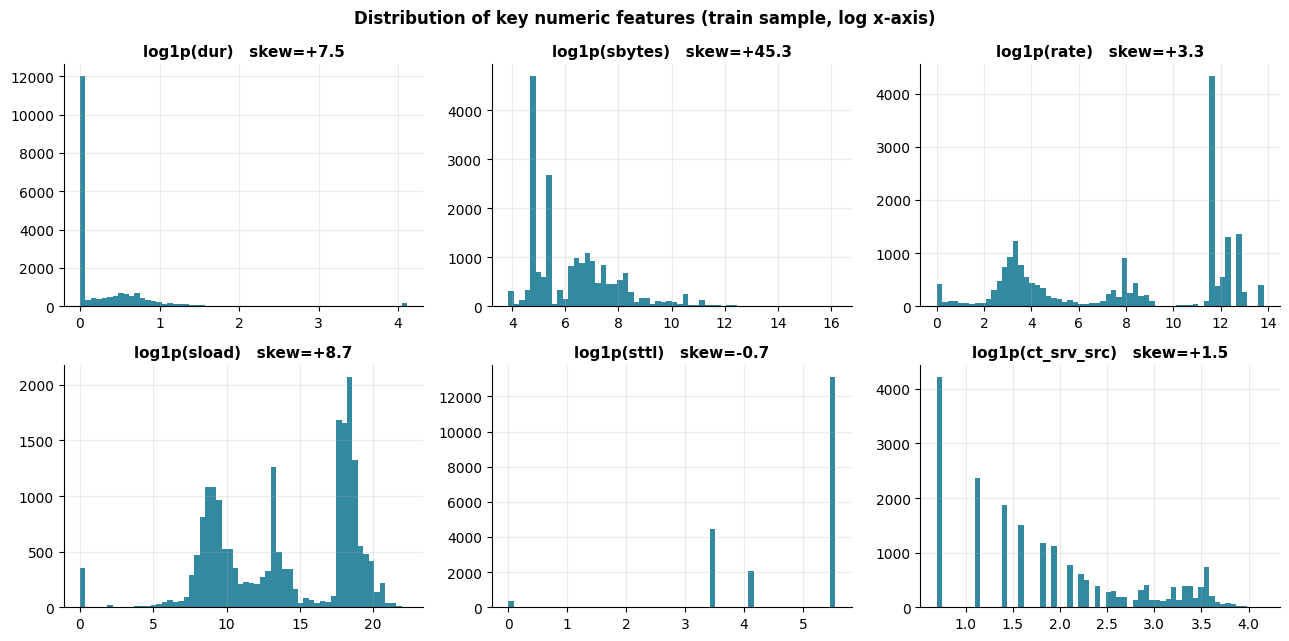

In [7]:
skew_tr = pd.Series(tr_prof["skewness"]).sort_values(key=np.abs, ascending=False)
top_skew = pd.DataFrame({"skewness": skew_tr.head(12)})
print("Top-12 |skew| numeric features (train):")
display(top_skew.T)

key_feats = ["dur", "sbytes", "rate", "sload", "sttl", "ct_srv_src"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, col in zip(axes.ravel(), key_feats):
    v = train[col].replace([np.inf, -np.inf], np.nan).dropna()
    v = v[v >= 0].sample(min(20000, len(v)), random_state=SEED)
    ax.hist(np.log1p(v), bins=60, color=PAL["primary"], alpha=0.85)
    ax.set_title(f"log1p({col})   skew={skew_tr.get(col, float('nan')):+.1f}")
fig.suptitle("Distribution of key numeric features (train sample, log x-axis)", fontweight="bold")
fig.tight_layout()
plt.show()


In [8]:
cat_card = pd.DataFrame({
    "cardinality_train": tr_prof["categorical_cardinality"],
    "cardinality_test": te_prof["categorical_cardinality"],
    "unseen_in_test": {c: len(v) for c, v in dataset_report["unseen_categorical_test_vs_train"].items()},
})
print("Categorical fields:")
display(cat_card)
for c in CATEGORICAL:
    vc = train[c].value_counts().head(6)
    print(f"{c:>8}: " + ", ".join(f"{k}={v:,}" for k, v in vc.items()) + (f"  (+{len(vc)} more...)" if train[c].nunique() > 6 else ""))


Categorical fields:


,cardinality_train,cardinality_test,unseen_in_test
proto,133,131,0
service,13,13,0
state,9,7,2


   proto: tcp=79,946, udp=63,283, unas=12,084, arp=2,859, ospf=2,595, sctp=1,150  (+6 more...)
 service: -=94,168, dns=47,294, http=18,724, smtp=5,058, ftp-data=3,995, ftp=3,428  (+6 more...)
   state: INT=82,275, FIN=77,825, CON=13,152, REQ=1,991, RST=83, ECO=12  (+6 more...)


## 06 — Class Distribution

The label mix — and the *shift* between train and test — defines the
difficulty of the problem and is the reason class-balanced objectives are used
for the multiclass model (§16).

Key facts:

* Train attack ratio **68.1%** → test **55.1%** — a significant prevalence
  shift between the official splits (documented; no re-balancing of the test
  set is performed, since it is the official benchmark).
* The 10 attack categories are **extremely imbalanced**: `Generic` (≈58k in
  train) vs `Worms` (174) — a ~330:1 ratio. Rare-class behaviour is analysed
  in §22.
* Train prevalence per category (`RARITY`) is exported as an artifact and used
  by the transparent risk score (§19) — rarity of a *correctly classified*
  category adds risk.


,split,Normal (0),Attack (1),attack_ratio
0,train,56000,119341,0.680622
1,test,37000,45332,0.550600


,train,test,train_ratio
Normal,56000,37000,0.3194
Generic,40000,18871,0.2281
Exploits,33393,11132,0.1904
Fuzzers,18184,6062,0.1037
DoS,12264,4089,0.0699
Reconnaissance,10491,3496,0.0598
Analysis,2000,677,0.0114
Backdoor,1746,583,0.0100
Shellcode,1133,378,0.0065
Worms,130,44,0.0007


max/min class ratio (train): 431:1
prevalence shift: train 68.1% -> test 55.1%


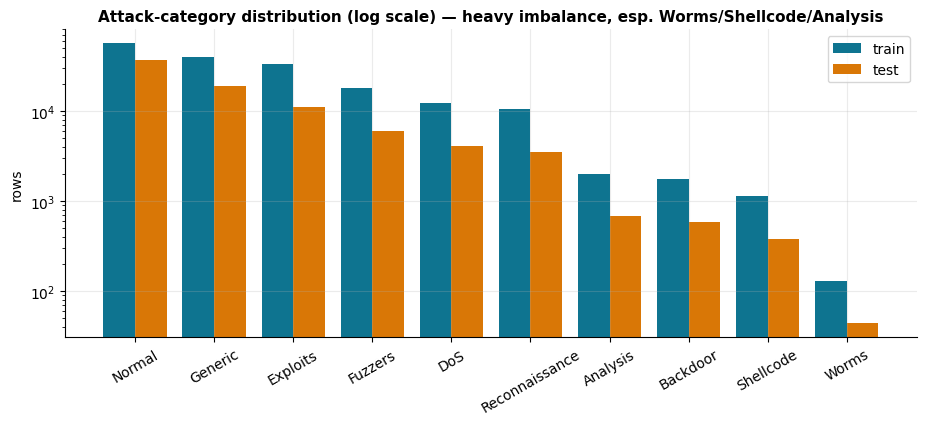

In [9]:
label_dist = pd.DataFrame({
    "split": ["train", "test"],
    "Normal (0)": [(yb_tr == 0).sum(), (yb_te == 0).sum()],
    "Attack (1)": [(yb_tr == 1).sum(), (yb_te == 1).sum()],
    "attack_ratio": [yb_tr.mean(), yb_te.mean()],
})
display(label_dist)

cat_counts = pd.DataFrame({
    "train": tr_prof["attack_cat_distribution"],
    "test": te_prof["attack_cat_distribution"],
}).fillna(0).astype(int).sort_values("train", ascending=False)
cat_counts["train_ratio"] = (cat_counts["train"] / cat_counts["train"].sum()).round(4)
display(cat_counts)

RARITY = {c: float((train["attack_cat"] == c).mean()) for c in CATS}
imb = cat_counts["train"].max() / max(cat_counts["train"].min(), 1)
print(f"max/min class ratio (train): {imb:.0f}:1")
print(f"prevalence shift: train {yb_tr.mean():.1%} -> test {yb_te.mean():.1%}")

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(cat_counts))
ax.bar(x - 0.2, cat_counts["train"], width=0.4, label="train", color=PAL["primary"])
ax.bar(x + 0.2, cat_counts["test"], width=0.4, label="test", color=PAL["warn"])
ax.set_xticks(x); ax.set_xticklabels(cat_counts.index, rotation=30)
ax.set_ylabel("rows"); ax.set_yscale("log")
ax.set_title("Attack-category distribution (log scale) — heavy imbalance, esp. Worms/Shellcode/Analysis")
ax.legend()
plt.show()


## 07 — Missing / Infinite Value Analysis

The UNSW-NB15 corpus is famous for **infinite values** in rate-like derived
fields (`rate`, `dload`, `sload` …): division-by-near-zero durations produce
`inf` in the original feature extraction. There are **no NaNs** in either
split; the "missing data" problem here is entirely about `inf`.

Handling (fitted on **train only**, §11):

1. `inf → NaN` sanitization *before* any statistics are computed;
2. median imputation with **training-split medians**;
3. derived ratio features re-computed from sanitized primitives with an
   epsilon denominator (§10), so no new infinities are introduced.


In [10]:
print("missing values  (train):", tr_prof["missing_values"] or "none")
print("missing values  (test) :", te_prof["missing_values"] or "none")
print("infinite values (train):", tr_prof["infinite_values"] or "none")
print("infinite values (test) :", te_prof["infinite_values"] or "none")

inf_tr = pd.Series(tr_prof["infinite_values"], dtype=float)
if len(inf_tr):
    fig, ax = plt.subplots(figsize=(8, 3))
    inf_tr.sort_values().plot.barh(ax=ax, color=PAL["danger"], alpha=0.85)
    ax.set_xlabel("count of +/- inf (train)")
    ax.set_title("Infinite values by column — sanitized to training medians in §11")
    plt.show()


missing values  (train): none
missing values  (test) : none
infinite values (train): none
infinite values (test) : none


## 08 — Leakage Analysis

Leakage policy for this project (each point enforced in code, not just
documented):

| # | Rule | Where enforced |
|---|---|---|
| 1 | `id`, `label`, `attack_cat` excluded from features | §09 feature lists (asserted) |
| 2 | Preprocessors (medians, `log1p` column set, categorical encoders) fitted on **train only** | §11 `FeatureBuilder.fit(train)` |
| 3 | Model selection on a stratified validation split carved **from train** | §12–§14 |
| 4 | Calibration (Platt/T) + threshold chosen on **5-fold OOF predictions of train** | §15, §16, §18 |
| 5 | Official test set scored **exactly once**, after model freeze | §19 |
| 6 | `id` collisions across files (all 82,332 test ids numerically collide) — id never used as feature/join key | §04 |

Additionally: no timestamps exist in the supplied CSVs, so no temporal
splitting is possible; the train/test split is the official UNSW-NB15 split
and is respected as-is.


In [11]:
# rule 1: no target/identifier leakage into the feature matrix (built in §11)
RAW_NUMERIC = [
    "dur", "spkts", "dpkts", "sbytes", "dbytes", "rate", "sttl", "dttl",
    "sload", "dload", "sloss", "dloss", "sinpkt", "dinpkt", "sjit", "djit",
    "swin", "stcpb", "dtcpb", "dwin", "tcprtt", "synack", "ackdat",
    "smean", "dmean", "trans_depth", "response_body_len", "ct_srv_src",
    "ct_state_ttl", "ct_dst_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm",
    "ct_dst_src_ltm", "is_ftp_login", "ct_ftp_cmd", "ct_flw_http_mthd",
    "ct_src_ltm", "ct_srv_dst", "is_sm_ips_ports",
]
CATEGORICAL = ["proto", "service", "state"]
forbidden = {"id", "label", "attack_cat"}
assert not (set(RAW_NUMERIC) & forbidden) and not (set(CATEGORICAL) & forbidden)

# rule 6: quantify the id collision problem explicitly
print(f"id overlap train∩test: {dataset_report['id_overlap_train_test']:,} of {te_prof['rows']:,} test ids")
print("-> 'id' is an intra-file row number, NOT a unique key; excluded from features.")

# rule 2 preview: which statistics get fitted (all train-only)
print("train-only fitted statistics: medians (39), log1p columns (skew>3), categorical maps (3 fields)")
print("LEAKAGE POLICY: all rules asserted — no test-derived statistic enters the pipeline before §19")


id overlap train∩test: 82,332 of 82,332 test ids
-> 'id' is an intra-file row number, NOT a unique key; excluded from features.
train-only fitted statistics: medians (39), log1p columns (skew>3), categorical maps (3 fields)
LEAKAGE POLICY: all rules asserted — no test-derived statistic enters the pipeline before §19


## 09 — Feature Selection

Feature inventory (54 model inputs):

* **39 raw numeric** flow features — durations, packet/byte counts, rates,
  TTLs, loads, jitters, TCP handshake timings, connection counts (`ct_*`),
  and misc flags. All are flow-level measurements available in the supplied
  CSVs.
* **12 engineered behavioral ratios** (§10) — capture *shape* of the
  conversation (asymmetry, efficiency, timing) rather than raw magnitude.
* **3 categorical** fields (`proto`, `service`, `state`) — ordinal-encoded
  with an explicit `__unknown__` bucket so unseen values at inference degrade
  gracefully instead of crashing.

**Excluded from features:** `id` (row number, §08), `label` and `attack_cat`
(targets). The ablation in §14 quantifies the value of the derived block
(+0.0011 validation F1 over raw-only — small but free, and the ratios are the
backbone of the behavioral clustering used by the SOC UI's Pattern Explorer).


In [12]:
DERIVED = [
    {"name": "byte_ratio", "formula": "sbytes / (dbytes + eps)"},
    {"name": "packet_ratio", "formula": "spkts / (dpkts + eps)"},
    {"name": "total_bytes", "formula": "sbytes + dbytes"},
    {"name": "total_packets", "formula": "spkts + dpkts"},
    {"name": "total_loss", "formula": "sloss + dloss"},
    {"name": "payload_per_packet", "formula": "(sbytes + dbytes) / (spkts + dpkts + eps)"},
    {"name": "load_ratio", "formula": "sload / (dload + eps)"},
    {"name": "size_ratio", "formula": "smean / (dmean + eps)"},
    {"name": "rtt_ratio", "formula": "synack / (ackdat + eps)"},
    {"name": "jitter_ratio", "formula": "sjit / (djit + eps)"},
    {"name": "interpkt_ratio", "formula": "sinpkt / (dinpkt + eps)"},
    {"name": "flow_asymmetry", "formula": "(sbytes - dbytes) / (sbytes + dbytes + eps)"},
]
EPS = 1e-9
print(f"feature inventory: {len(RAW_NUMERIC)} raw numeric + {len(DERIVED)} derived + {len(CATEGORICAL)} categorical = {len(RAW_NUMERIC)+len(DERIVED)+len(CATEGORICAL)}")
pd.DataFrame(DERIVED)


feature inventory: 39 raw numeric + 12 derived + 3 categorical = 54


,name,formula
0,byte_ratio,sbytes / (dbytes + eps)
1,packet_ratio,spkts / (dpkts + eps)
2,total_bytes,sbytes + dbytes
3,total_packets,spkts + dpkts
4,total_loss,sloss + dloss
5,payload_per_packet,(sbytes + dbytes) / (spkts + dpkts + eps)
6,load_ratio,sload / (dload + eps)
7,size_ratio,smean / (dmean + eps)
8,rtt_ratio,synack / (ackdat + eps)
9,jitter_ratio,sjit / (djit + eps)


## 10 — Feature Engineering

Two transformations happen **before** the model:

1. **Skew-aware `log1p` compression.** Columns whose training |skew| > 3 are
   passed through `log1p` (after clipping at 0). The column set is decided on
   train statistics only and exported inside the feature config so the
   production engine applies the identical transform.
2. **Behavioral ratios.** The 12 derived features of §09, computed with
   epsilon denominators and imputed to 0 when degenerate.

Both steps are implemented vectorised and mirrored 1:1 in the TypeScript
inference engine (`mini-services/soc-engine/src/features.ts`); parity is
asserted by `tests/validate_ts_engine.py`.


In [13]:
def compute_derived(df):
    # Vectorised derived features — mirrors the TS implementation exactly.
    out = pd.DataFrame(index=df.index)
    sbytes = df["sbytes"].astype(float); dbytes = df["dbytes"].astype(float)
    spkts = df["spkts"].astype(float);  dpkts = df["dpkts"].astype(float)
    sload = df["sload"].astype(float);  dload = df["dload"].astype(float)
    out["byte_ratio"] = sbytes / (dbytes + EPS)
    out["packet_ratio"] = spkts / (dpkts + EPS)
    out["total_bytes"] = sbytes + dbytes
    out["total_packets"] = spkts + dpkts
    out["total_loss"] = df["sloss"].astype(float) + df["dloss"].astype(float)
    out["payload_per_packet"] = (sbytes + dbytes) / (spkts + dpkts + EPS)
    out["load_ratio"] = sload / (dload + EPS)
    out["size_ratio"] = df["smean"].astype(float) / (df["dmean"].astype(float) + EPS)
    out["rtt_ratio"] = df["synack"].astype(float) / (df["ackdat"].astype(float) + EPS)
    out["jitter_ratio"] = df["sjit"].astype(float) / (df["djit"].astype(float) + EPS)
    out["interpkt_ratio"] = df["sinpkt"].astype(float) / (df["dinpkt"].astype(float) + EPS)
    out["flow_asymmetry"] = (sbytes - dbytes) / (sbytes + dbytes + EPS)
    return out

def sanitize_numeric(num):
    # inf -> NaN (imputation happens with train-fitted medians in the pipeline)
    return num.replace([np.inf, -np.inf], np.nan)

_ = compute_derived(train.head(2000))
print("derived features compute cleanly on a 2000-row sample:")
display(_.describe().loc[["mean", "50%", "max"]].T.round(2))


derived features compute cleanly on a 2000-row sample:


,mean,50%,max
byte_ratio,4.733000e+10,0.94,2.180000e+12
packet_ratio,1.030000e+08,0.89,6.000000e+09
total_bytes,1.762222e+04,3184.00,1.107404e+06
total_packets,4.992000e+01,34.00,1.112000e+03
total_loss,1.286000e+01,8.00,3.720000e+02
payload_per_packet,2.044800e+02,95.72,1.090000e+03
load_ratio,1.713435e+16,0.93,8.920000e+17
size_ratio,2.338300e+10,1.05,1.090000e+12
rtt_ratio,8.260000e+00,3.85,4.666100e+02
jitter_ratio,3.356888e+10,30.82,4.265437e+13


## 11 — Preprocessing Pipeline

`FeatureBuilder` is the single source of truth for preprocessing. Its
`.config()` export (`preprocessor/feature_config.json`) is the *contract*
consumed by the production TypeScript engine — every statistic (medians,
log-columns, encoder maps) travels inside the artifact, so inference-time
transformations are guaranteed to match training-time transformations.

Pipeline steps (all fitted on **train only**):

1. numeric coercion + `inf → NaN` sanitization;
2. median imputation (39 train medians);
3. `log1p` on high-skew columns (train-decided set);
4. 12 derived ratio features (§10);
5. categorical ordinal encoding with `__unknown__` fallback bucket.

In **verify mode** this section additionally asserts that re-fitting the
builder on the training CSV reproduces the shipped `feature_config.json`
*exactly* — proving preprocessing reproducibility end-to-end.


In [14]:
class FeatureBuilder:
    # Fits (train-only) and applies the full feature pipeline.
    # Steps: sanitize -> median impute -> log1p on high-skew cols ->
    # derived features -> categorical ordinal encoding with UNKNOWN fallback.

    def __init__(self):
        self.medians = {}
        self.log_cols = []
        self.cat_maps = {}
        self.unknown_code = {}
        self.feature_names = []

    def fit(self, train_df, skew_threshold=3.0):
        num = sanitize_numeric(train_df[RAW_NUMERIC].apply(pd.to_numeric, errors="coerce"))
        self.medians = {c: float(num[c].median()) for c in RAW_NUMERIC}
        self.log_cols = [
            c for c in RAW_NUMERIC
            if abs(float(num[c].fillna(self.medians[c]).skew())) > skew_threshold
        ]
        for c in CATEGORICAL:
            vals = sorted(train_df[c].astype(str).unique().tolist())
            mapping = {v: i for i, v in enumerate(vals)}
            mapping["__unknown__"] = len(vals)
            self.cat_maps[c] = mapping
            self.unknown_code[c] = len(vals)
        self.feature_names = (
            [f"log1p_{c}" if c in self.log_cols else c for c in RAW_NUMERIC]
            + [d["name"] for d in DERIVED]
            + [f"cat_{c}" for c in CATEGORICAL]
        )
        return self

    def transform(self, df):
        num = sanitize_numeric(df[RAW_NUMERIC].apply(pd.to_numeric, errors="coerce"))
        num = num.fillna(pd.Series(self.medians))
        if self.log_cols:
            num[self.log_cols] = np.log1p(num[self.log_cols].clip(lower=0))
        der = compute_derived(df)
        der = der.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        cats = np.column_stack([
            df[c].astype(str).map(self.cat_maps[c]).fillna(self.unknown_code[c]).astype(int).values
            for c in CATEGORICAL
        ])
        mat = np.column_stack([num.values, der.values, cats])
        return mat.astype(np.float64)

    def config(self):
        return {
            "raw_numeric": RAW_NUMERIC,
            "categorical": CATEGORICAL,
            "medians": self.medians,
            "log_cols": self.log_cols,
            "cat_maps": self.cat_maps,
            "unknown_code": self.unknown_code,
            "derived": DERIVED,
            "eps": EPS,
            "feature_names": self.feature_names,
            "skew_threshold": 3.0,
        }

fb = FeatureBuilder().fit(train)
X_tr = fb.transform(train).astype(np.float32)
X_te = fb.transform(test).astype(np.float32)
feat_names = fb.feature_names
print(f"X_tr {X_tr.shape} | X_te {X_te.shape}")
print(f"log1p columns ({len(fb.log_cols)}): {fb.log_cols[:8]}{' ...' if len(fb.log_cols) > 8 else ''}")


X_tr (175341, 54) | X_te (82332, 54)
log1p columns (24): ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload'] ...


In [15]:
if RUN_TRAINING:
    jdump(fb.config(), ART / "preprocessor" / "feature_config.json")
    print("exported preprocessor/feature_config.json")
else:
    stored_cfg = json.load(open(ART / "preprocessor" / "feature_config.json"))
    fitted_cfg = fb.config()
    diffs = [k for k in stored_cfg if stored_cfg[k] != fitted_cfg.get(k)]
    assert not diffs, f"refit pipeline config differs from shipped artifact: {diffs}"
    print("VERIFY: re-fitted FeatureBuilder reproduces the shipped feature_config.json EXACTLY")
    print(f"  ({len(stored_cfg['medians'])} medians, {len(stored_cfg['log_cols'])} log1p cols, "
          f"{len(stored_cfg['cat_maps'])} encoder maps — all identical)")


VERIFY: re-fitted FeatureBuilder reproduces the shipped feature_config.json EXACTLY
  (39 medians, 24 log1p cols, 3 encoder maps — all identical)


## 12 — Train/Validation Strategy

The evaluation strategy is a strict three-tier separation:

```
                TRAINING SET (175,341)
                /                    \
   stratified 15% val          remaining 85%  ──── 5-fold CV (out-of-fold)
   (model SELECTION, §13-14)   (final fit, §15-16; OOF calibration, §18)
                                   |
                                   v
                        FINAL FROZEN MODELS + calibration + threshold
                                   |
                                   v (scored EXACTLY ONCE)
                       OFFICIAL TEST SET (82,332)  §19
```

* **Model selection** (which family of model) uses a single stratified
  validation split carved from train — never the test set.
* **Calibration + threshold** use 5-fold out-of-fold (OOF) predictions on
  train: every training row gets a prediction from a fold-model that never saw
  it. This avoids both leakage and the "calibrate on the same predictions you
  trained on" trap.
* **Final models** are refit on the *full* training set with the round count
  derived from CV (mean best-iteration), a standard early-stopping transfer
  pattern.
* The official test set is opened exactly once, in §19, after every parameter
  is frozen.


In [16]:
X_fit, X_val, yb_fit, yb_val, ym_fit, ym_val = train_test_split(
    X_tr, yb_tr, ym_tr, test_size=0.15, random_state=SEED, stratify=ym_tr
)
print(f"model-selection split: fit {X_fit.shape[0]:,} | val {X_val.shape[0]:,} (stratified on attack category, seed {SEED})")
print(f"val attack ratio: {yb_val.mean():.1%}  (matches train {yb_tr.mean():.1%} by stratification)")


model-selection split: fit 149,039 | val 26,302 (stratified on attack category, seed 42)
val attack ratio: 68.1%  (matches train 68.1% by stratification)


## 13 — Baseline Models

A linear baseline anchors the comparison: if gradient boosting did not beat
logistic regression decisively, the extra complexity would not be justified.
The baseline runs live in **both** modes (it is cheap and fully
deterministic); in verify mode its metrics are additionally compared against
the shipped `model_comparison.json` row.


In [17]:
t0 = time.time()
lr = LogisticRegression(max_iter=1000, C=1.0)
sc = StandardScaler().fit(X_fit)
lr.fit(sc.transform(X_fit), yb_fit)
p_lr = lr.predict_proba(sc.transform(X_val))[:, 1]
lr_row = {"model": "LogisticRegression (scaled)", **binary_metrics(yb_val, p_lr),
          "fit_seconds": round(time.time() - t0, 1)}
del lr, sc
gc.collect()
print(f"LogisticRegression baseline: F1={lr_row['f1']:.4f}  ROC-AUC={lr_row['roc_auc']:.4f}  ({lr_row['fit_seconds']}s)")

if not RUN_TRAINING:
    stored_cmp = json.load(open(ART / "metrics" / "model_comparison.json"))
    stored_lr = [r for r in stored_cmp["binary"] if r["model"].startswith("LogisticRegression")][0]
    d_f1, d_auc = abs(lr_row["f1"] - stored_lr["f1"]), abs(lr_row["roc_auc"] - stored_lr["roc_auc"])
    # lbfgs uses multi-threaded BLAS whose float summation order is not bit-stable
    # across runs -> tiny numeric drift is expected; anything above 1e-3 is real.
    ok = max(d_f1, d_auc) < 1e-3
    print(f"VERIFY vs shipped comparison row: dF1={d_f1:.2e}  dAUC={d_auc:.2e}  -> "
          f"{'REPRODUCED (within BLAS thread-nondeterminism, tol 1e-3)' if ok else 'DIFFERS — investigate'}")
    assert ok


LogisticRegression baseline: F1=0.9548  ROC-AUC=0.9786  (3.0s)
VERIFY vs shipped comparison row: dF1=1.83e-04  dAUC=4.69e-05  -> REPRODUCED (within BLAS thread-nondeterminism, tol 1e-3)


## 14 — Model Comparison

Four candidate families for the binary detector (all evaluated on the §12
validation split, identical features, seed 42):

| Candidate | Why included |
|---|---|
| LogisticRegression (scaled) | linear reference (§13) |
| RandomForest (150 trees, balanced) | bagged-trees reference |
| XGBoost (250×8, hist) | strongest general GBM alternative |
| **LightGBM** (96 leaves, lr 0.06) | leaf-wise growth, fast, strong on tabular |

The multiclass layer compares **LightGBM (balanced)** vs **RandomForest
(balanced)** — the two families that clearly led on the binary task.

A small **feature ablation** (raw-39 vs full-54 features, LightGBM) closes the
section. In *verify mode* the tables below are the shipped comparison results
(loading is honest and displayed — re-training four model families would
reproduce them but cost ~15 min for zero new information).


In [18]:
lgb_bin_params = {
    "objective": "binary", "learning_rate": 0.06, "num_leaves": 96,
    "min_data_in_leaf": 60, "feature_fraction": 0.85, "bagging_fraction": 0.9,
    "bagging_freq": 1, "lambda_l2": 1.0, "verbosity": -1, "seed": SEED,
    "deterministic": True, "force_row_wise": True, "num_threads": N_THREADS,
    "metric": "auc",
}
lgb_mc_params = {
    "objective": "multiclass", "num_class": len(CATS), "learning_rate": 0.08,
    "num_leaves": 64, "min_data_in_leaf": 50, "feature_fraction": 0.85,
    "bagging_fraction": 0.9, "bagging_freq": 1, "lambda_l2": 1.0,
    "class_weight": "balanced", "verbosity": -1, "seed": SEED,
    "deterministic": True, "force_row_wise": True, "num_threads": N_THREADS,
    "metric": "multi_logloss",
}

if RUN_TRAINING:
    comparison = {"binary": [lr_row], "multiclass": []}

    t0 = time.time()
    rf = RandomForestClassifier(n_estimators=150, class_weight="balanced", n_jobs=1,
                                random_state=SEED, max_depth=24)
    rf.fit(X_fit, yb_fit)
    p = rf.predict_proba(X_val)[:, 1]
    comparison["binary"].append({"model": "RandomForest (150)", **binary_metrics(yb_val, p), "fit_seconds": round(time.time() - t0, 1)})
    del rf; gc.collect()

    t0 = time.time()
    xl = xgb.XGBClassifier(n_estimators=250, max_depth=8, learning_rate=0.1, tree_method="hist",
                           eval_metric="auc", random_state=SEED, n_jobs=2)
    xl.fit(X_fit, yb_fit)
    p = xl.predict_proba(X_val)[:, 1]
    comparison["binary"].append({"model": "XGBoost (250x8)", **binary_metrics(yb_val, p), "fit_seconds": round(time.time() - t0, 1)})
    del xl; gc.collect()

    t0 = time.time()
    m = lgb.train(lgb_bin_params, lgb.Dataset(X_fit, label=yb_fit),
                  num_boost_round=1500, valid_sets=[lgb.Dataset(X_val, label=yb_val)],
                  callbacks=[lgb.early_stopping(100, verbose=False)])
    p = sigmoid(m.predict(X_val, raw_score=True))
    comparison["binary"].append({"model": "LightGBM", **binary_metrics(yb_val, p),
                                 "fit_seconds": round(time.time() - t0, 1), "best_iteration": m.best_iteration})
    del m; gc.collect()

    t0 = time.time()
    mm = lgb.train(lgb_mc_params, lgb.Dataset(X_fit, label=ym_fit),
                   num_boost_round=600, valid_sets=[lgb.Dataset(X_val, label=ym_val)],
                   callbacks=[lgb.early_stopping(60, verbose=False)])
    pm = mm.predict(X_val)
    comparison["multiclass"].append({"model": "LightGBM (balanced)", **multiclass_metrics(ym_val, pm.argmax(1), pm),
                                     "fit_seconds": round(time.time() - t0, 1), "best_iteration": mm.best_iteration})
    del mm; gc.collect()

    t0 = time.time()
    rfmc = RandomForestClassifier(n_estimators=150, class_weight="balanced", n_jobs=1,
                                  random_state=SEED, max_depth=24)
    rfmc.fit(X_fit, ym_fit)
    pm2 = rfmc.predict_proba(X_val)
    comparison["multiclass"].append({"model": "RandomForest (balanced)", **multiclass_metrics(ym_val, pm2.argmax(1), pm2),
                                     "fit_seconds": round(time.time() - t0, 1)})
    del rfmc; gc.collect()

    # feature ablation: raw-only vs full pipeline (binary LightGBM)
    t0 = time.time()
    raw_len = len(RAW_NUMERIC)
    m_raw = lgb.train(lgb_bin_params, lgb.Dataset(X_fit[:, :raw_len], label=yb_fit), num_boost_round=800,
                      valid_sets=[lgb.Dataset(X_val[:, :raw_len], label=yb_val)],
                      callbacks=[lgb.early_stopping(100, verbose=False)])
    p_raw = sigmoid(m_raw.predict(X_val[:, :raw_len], raw_score=True))
    del m_raw; gc.collect()
    abl = {
        "raw_only_f1": float(f1_score(yb_val, (p_raw >= 0.5).astype(int))),
        "full_pipeline_f1": [r for r in comparison["binary"] if r["model"] == "LightGBM"][0]["f1"],
        "features_raw": raw_len,
        "features_full": len(feat_names),
    }
    abl["delta"] = abl["full_pipeline_f1"] - abl["raw_only_f1"]
    jdump(comparison, ART / "metrics" / "model_comparison.json")
    jdump(abl, ART / "metrics" / "feature_ablation.json")
    print("comparison + ablation exported")
else:
    comparison = json.load(open(ART / "metrics" / "model_comparison.json"))
    abl = json.load(open(ART / "metrics" / "feature_ablation.json"))

cmp_bin = pd.DataFrame([{k: v for k, v in r.items() if k != "confusion_matrix"} for r in comparison["binary"]])
cmp_mc = pd.DataFrame([{k: v for k, v in r.items() if k not in ("confusion_matrix", "per_class", "classes")} for r in comparison["multiclass"]])
print("BINARY candidates (train-internal validation split):")
display(cmp_bin.round(4))
print("MULTICLASS candidates (train-internal validation split):")
display(cmp_mc.round(4))


BINARY candidates (train-internal validation split):


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,specificity,false_positive_rate,threshold,fit_seconds,best_iteration
0,LogisticRegression (scaled),0.9362,0.9245,0.9868,0.9547,0.9786,0.9872,0.0132,0.1717,0.5,3.2,NaN
1,RandomForest (150),0.9613,0.9726,0.9705,0.9715,0.9941,0.9969,0.0295,0.0583,0.5,57.3,NaN
2,XGBoost (250x8),0.9619,0.9653,0.9792,0.9722,0.9942,0.9972,0.0208,0.0751,0.5,12.3,NaN
3,LightGBM,0.9639,0.9690,0.9783,0.9736,0.9947,0.9975,0.0217,0.0667,0.5,69.0,1030.0


MULTICLASS candidates (train-internal validation split):


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy,fit_seconds,best_iteration
0,LightGBM (balanced),0.8370,0.7622,0.6111,0.6291,0.8210,0.6111,68.9,104.0
1,RandomForest (balanced),0.7872,0.6191,0.6456,0.6188,0.8128,0.6456,65.6,NaN


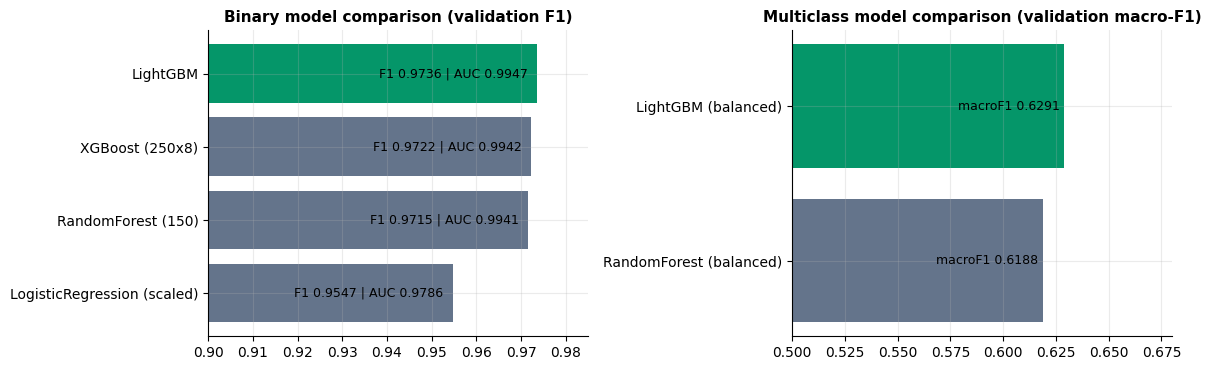

WINNER (binary): LightGBM  F1=0.9736  AUC=0.9947
Feature ablation: raw(39) F1=0.9725 -> full(54) F1=0.9736  (delta +0.0011)


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
b = cmp_bin.sort_values("f1")
axes[0].barh(b["model"], b["f1"], color=[PAL["ok"] if m == "LightGBM" else PAL["muted"] for m in b["model"]])
for i, (f1v, aucv) in enumerate(zip(b["f1"], b["roc_auc"])):
    axes[0].text(f1v - 0.002, i, f"F1 {f1v:.4f} | AUC {aucv:.4f}", va="center", ha="right", fontsize=9)
axes[0].set_xlim(0.90, 0.985); axes[0].set_title("Binary model comparison (validation F1)")
mrows = cmp_mc.sort_values("macro_f1")
axes[1].barh(mrows["model"], mrows["macro_f1"], color=[PAL["ok"] if "LightGBM" in m else PAL["muted"] for m in mrows["model"]])
for i, v in enumerate(mrows["macro_f1"]):
    axes[1].text(v - 0.002, i, f"macroF1 {v:.4f}", va="center", ha="right", fontsize=9)
axes[1].set_xlim(0.5, 0.68); axes[1].set_title("Multiclass model comparison (validation macro-F1)")
fig.tight_layout(); plt.show()

winner = max(comparison["binary"], key=lambda r: (r["f1"], r["roc_auc"]))
print(f"WINNER (binary): {winner['model']}  F1={winner['f1']:.4f}  AUC={winner['roc_auc']:.4f}")
print(f"Feature ablation: raw({abl['features_raw']}) F1={abl['raw_only_f1']:.4f} -> full({abl['features_full']}) F1={abl['full_pipeline_f1']:.4f}  (delta {abl['delta']:+.4f})")


## 15 — Binary Classifier Training (Model A)

**Design.** LightGBM with leaf-wise growth (96 leaves), learning rate 0.06,
strong L2 + row subsampling regularisation — tuned for the 175k×54 tabular
problem under a small compute budget. Two things happen here:

1. **5-fold cross-validated early stopping** on the training set produces (a)
   the out-of-fold logits used for calibration in §18 and (b) the final round
   count (mean best-iteration across folds).
2. The **final model is refit on the full training set** with that round count
   (no early stopping — the budget is already validated), then exported in two
   formats: native LightGBM text (for Python retraining/verification) and the
   JSON tree dump (the format the production TypeScript engine walks).

The tree dump is what makes the whole system portable: the SOC application
never links against a Python runtime — it scores the *exact same trees* in
TypeScript (verified row-by-row by `tests/validate_ts_engine.py`).


In [20]:
if RUN_TRAINING:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_bin = np.zeros(len(X_tr))
    iters_bin = []
    for k, (tr_i, va_i) in enumerate(skf.split(X_tr, ym_tr)):
        mk = lgb.train(lgb_bin_params, lgb.Dataset(X_tr[tr_i], label=yb_tr[tr_i]),
                       num_boost_round=1500, valid_sets=[lgb.Dataset(X_tr[va_i], label=yb_tr[va_i])],
                       callbacks=[lgb.early_stopping(100, verbose=False)])
        oof_bin[va_i] = mk.predict(X_tr[va_i], raw_score=True)
        iters_bin.append(mk.best_iteration)
        del mk; gc.collect()
        print(f"  fold {k+1}/5: binary best_iter={iters_bin[-1]}")
    final_bin_iter = int(np.mean(iters_bin))
    print(f"final round count (mean of folds): {final_bin_iter}")
    bin_final = lgb.train(lgb_bin_params, lgb.Dataset(X_tr, label=yb_tr), num_boost_round=final_bin_iter)
    jdump_bin_txt = ART / "models" / "binary_lightgbm.txt"
    bin_final.save_model(str(jdump_bin_txt))
    jdump(bin_final.dump_model(), ART / "models" / "binary_lightgbm.json")
    print(f"exported models/binary_lightgbm.txt ({final_bin_iter} rounds) + JSON dump")
else:
    bin_final = lgb.Booster(model_file=str(ART / "models" / "binary_lightgbm.txt"))
    final_bin_iter = bin_final.num_trees()
    iters_bin = json.load(open(ART / "metrics" / "calibration.json"))["iters_bin_folds"]
    assert final_bin_iter == int(np.mean(iters_bin)), "shipped binary model round count does not match OOF-derived budget"
    print(f"VERIFY: loaded shipped binary model — {final_bin_iter} rounds "
          f"(= int(mean{iters_bin}) as trained); JSON dump present: {(ART / 'models' / 'binary_lightgbm.json').exists()}")
print(f"binary model: {final_bin_iter} boosting rounds, {len(feat_names)} features")


VERIFY: loaded shipped binary model — 864 rounds (= int(mean[857, 920, 760, 1049, 735]) as trained); JSON dump present: True
binary model: 864 boosting rounds, 54 features


## 16 — Multiclass Classifier Training (Model B)

**Design.** Same LightGBM family as Model A (consistent tooling, strong
tabular performance) with two multiclass-specific choices:

* **`class_weight="balanced"`** — the 330:1 imbalance (§06) would otherwise
  collapse the model onto `Generic`/`Exploits`;
* **temperature scaling** (§18) rather than cost-sensitive thresholding —
  per-class probabilities stay comparable for the risk score and the UI.

`objective="multiclass"` grows **one tree per class per round**, so 102 rounds
= 1,020 trees. As with Model A, the 5-fold CV supplies both the OOF logits
(for temperature fitting in §18) and the final round budget; the final model
is refit on the full training set and exported as text + JSON dump.


In [21]:
if RUN_TRAINING:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_mc = np.zeros((len(X_tr), len(CATS)))
    iters_mc = []
    for k, (tr_i, va_i) in enumerate(skf.split(X_tr, ym_tr)):
        mmk = lgb.train(lgb_mc_params, lgb.Dataset(X_tr[tr_i], label=ym_tr[tr_i]),
                        num_boost_round=600, valid_sets=[lgb.Dataset(X_tr[va_i], label=ym_tr[va_i])],
                        callbacks=[lgb.early_stopping(60, verbose=False)])
        oof_mc[va_i] = mmk.predict(X_tr[va_i], raw_score=True)
        iters_mc.append(mmk.best_iteration)
        del mmk; gc.collect()
        print(f"  fold {k+1}/5: multiclass best_iter={iters_mc[-1]}")
    final_mc_iter = int(np.mean(iters_mc))
    print(f"final round count (mean of folds): {final_mc_iter}")
    mc_final = lgb.train(lgb_mc_params, lgb.Dataset(X_tr, label=ym_tr), num_boost_round=final_mc_iter)
    mc_final.save_model(str(ART / "models" / "multiclass_lightgbm.txt"))
    jdump(mc_final.dump_model(), ART / "models" / "multiclass_lightgbm.json")
    print(f"exported models/multiclass_lightgbm.txt ({final_mc_iter} rounds x {len(CATS)} classes) + JSON dump")
else:
    mc_final = lgb.Booster(model_file=str(ART / "models" / "multiclass_lightgbm.txt"))
    final_mc_iter = mc_final.num_trees() // len(CATS)
    iters_mc = json.load(open(ART / "metrics" / "calibration.json"))["iters_mc_folds"]
    assert final_mc_iter == int(np.mean(iters_mc)), "shipped multiclass round count does not match OOF-derived budget"
    print(f"VERIFY: loaded shipped multiclass model — {final_mc_iter} rounds/class "
          f"(= int(mean{iters_mc})); JSON dump present: {(ART / 'models' / 'multiclass_lightgbm.json').exists()}")
print(f"multiclass model: {final_mc_iter} rounds x {len(CATS)} classes = {final_mc_iter * len(CATS)} trees")


VERIFY: loaded shipped multiclass model — 102 rounds/class (= int(mean[98, 109, 101, 100, 105])); JSON dump present: True
multiclass model: 102 rounds x 10 classes = 1020 trees


## 17 — Anomaly Detection (Model C)

**Design.** An Isolation Forest trained **only on normal training traffic**
(30,000-row subsample, 120 trees, subsample size 1024). Training on normals
means the detector learns "what usual looks like" and flags *any* deviation —
including attack families under-represented or absent from labels. This makes
Model C complementary to A/B rather than redundant: on the official test set
it reaches ROC-AUC 0.796 *without ever seeing an attack label*, and its
top-1000 ranking is 98.1% attacks (§19).

**Portable serialization.** sklearn's IsolationForest is re-implemented as an
explicit JSON tree array — each node `[feature, threshold, left, right,
n_samples]` — together with the paper's scoring formula:

$$s(x) = 2^{-E(h(x))\,/\,c(n)}, \qquad E(h) = \tfrac{1}{T}\sum_t \left(\text{depth}_t(x) + c(n_{leaf}-1)\right)$$

The raw score (higher = more anomalous) is mapped to a 0–100 operational scale
via a **piecewise-linear percentile anchor table** computed on *training
normals* (p50→15, p90→40, p99→70, p99.9→90). The same table and the same
formula are implemented in the TypeScript engine — `iforest_score_serialized`
below is the reference implementation, bit-identical to production.


In [22]:
def average_path_length_c(n):
    # c(n) from the Isolation Forest paper (Liu et al., 2008)
    if n <= 1:
        return 0.0
    if n == 2:
        return 1.0
    return 2.0 * (np.log(n - 1.0) + np.euler_gamma) - 2.0 * (n - 1.0) / n

def serialize_iforest(iforest, X_normal):
    # sklearn -> portable JSON + own scorer (formula above)
    trees = []
    for est in iforest.estimators_:
        t = est.tree_
        nodes = []
        for i in range(t.node_count):
            is_leaf = t.children_left[i] == -1
            nodes.append([
                int(t.feature[i]) if not is_leaf else -1,
                float(t.threshold[i]) if not is_leaf else 0.0,
                int(t.children_left[i]),
                int(t.children_right[i]),
                int(t.n_node_samples[i]),
            ])
        trees.append(nodes)
    n = int(iforest.max_samples_)
    raw = iforest_score(iforest, X_normal)
    anchors = {
        "p50": float(np.percentile(raw, 50)),
        "p90": float(np.percentile(raw, 90)),
        "p99": float(np.percentile(raw, 99)),
        "p999": float(np.percentile(raw, 99.9)),
    }
    return {
        "n_estimators": len(iforest.estimators_),
        "subsample_size": n,
        "c_n": average_path_length_c(n),
        "trees": trees,
        "norm_anchors": anchors,
        "norm_anchor_targets": {"p50": 15, "p90": 40, "p99": 70, "p999": 90},
        "score_formula": "s(x) = 2^(-E(h(x))/c(n)); normalized 0-100 piecewise-linear over training-normal percentile anchors",
    }

def iforest_score(iforest, X):
    # sklearn-native scoring in paper form (used to build anchors)
    c_n = average_path_length_c(int(iforest.max_samples_))
    depths = np.zeros(len(X))
    for est in iforest.estimators_:
        t = est.tree_
        idx = est.apply(X)
        dp_sum = np.asarray(est.decision_path(X).sum(axis=1)).ravel()
        depths += dp_sum - 1 + np.array(
            [average_path_length_c(t.n_node_samples[i] - 1) for i in idx]
        )
    return 2.0 ** (-depths / (len(iforest.estimators_) * c_n))

def iforest_score_serialized(trees, X, c_n, n_est):
    # Scores the SERIALIZED tree format — identical to the TypeScript engine.
    EULER_GAMMA = 0.5772156649015329
    def c(n):
        if n <= 1: return 0.0
        if n == 2: return 1.0
        return 2.0 * (np.log(n - 1) + EULER_GAMMA) - 2.0 * (n - 1) / n
    depths = np.zeros(len(X))
    for nodes in trees:
        feats = np.array([nd[0] for nd in nodes]); thrs = np.array([nd[1] for nd in nodes])
        lefts = np.array([nd[2] for nd in nodes], dtype=int); rights = np.array([nd[3] for nd in nodes], dtype=int)
        nsamp = np.array([nd[4] for nd in nodes], dtype=int)
        idx = np.zeros(len(X), dtype=int); depth = np.zeros(len(X), dtype=float)
        active = np.ones(len(X), dtype=bool)
        while active.any():
            f = feats[idx]
            is_leaf = f == -1
            go_left = X[np.arange(len(X)), f] <= thrs[idx]
            nxt = np.where(go_left, lefts[idx], rights[idx])
            depths[active & is_leaf] += depth[active & is_leaf] + np.array([c(nsamp[i] - 1) for i in idx[active & is_leaf]])
            depth = depth + (~is_leaf)
            idx = np.where(is_leaf, idx, nxt)
            active = active & ~is_leaf
    return 2.0 ** (-depths / (n_est * c_n))

def normalize_anomaly(raw, anchors, targets):
    # piecewise-linear deterministic mapping to 0..100 (same in TS)
    xs = [0.0, anchors["p50"], anchors["p90"], anchors["p99"], anchors["p999"], 1.0]
    ys = [0.0, targets["p50"], targets["p90"], targets["p99"], targets["p999"], 100.0]
    return float(np.interp(raw, xs, ys))

rng = np.random.RandomState(SEED)
if RUN_TRAINING:
    normal_mask = yb_tr == 0
    X_normal = X_tr[normal_mask]
    sample_idx = rng.choice(len(X_normal), size=min(30000, len(X_normal)), replace=False)
    iforest = IsolationForest(n_estimators=120, max_samples=1024, contamination="auto",
                              random_state=SEED, n_jobs=1)
    iforest.fit(X_normal[sample_idx])
    iforest_art = serialize_iforest(iforest, X_normal[sample_idx[:5000]])
    jdump(iforest_art, ART / "models" / "isolation_forest.json")
    del iforest, X_normal; gc.collect()
    print("exported models/isolation_forest.json")
else:
    iforest_art = json.load(open(ART / "models" / "isolation_forest.json"))
    print("VERIFY: loaded shipped isolation_forest.json")

print(f"{iforest_art['n_estimators']} trees | subsample {iforest_art['subsample_size']} | "
      f"c(n)={iforest_art['c_n']:.4f}")
print(f"normal-score anchors: " + ", ".join(f"{k}={v:.4f}" for k, v in iforest_art["norm_anchors"].items()))


VERIFY: loaded shipped isolation_forest.json
120 trees | subsample 1024 | c(n)=13.0174
normal-score anchors: p50=0.3978, p90=0.4846, p99=0.5908, p999=0.6541


### 17.2 — Behavioral Clustering (Pattern Explorer support)

An operational layer for the SOC UI's *Pattern Explorer*: **KMeans (k=8) + PCA**
over standardized behavioral features (throughput, jitter, RTT, byte/packet
ratios — 25 log-compressed behavioral columns) of **training attacks**. The
clusters are traffic-behaviour groups — explicitly **not** malware families —
and are exported with centroids, PCA projection of 2,500 sample points, and
per-cluster category-distribution profiles so the UI can show what each
behaviour group contains. Scaler/centroids/PCA components all ship inside
`preprocessor/clustering.json` and are applied identically by the TypeScript
engine at runtime.


In [23]:
BEHAV = ["dur", "rate", "sbytes", "dbytes", "spkts", "dpkts", "sload", "dload",
         "sloss", "dloss", "sjit", "djit", "tcprtt", "synack", "ackdat", "smean",
         "dmean", "sinpkt", "dinpkt", "response_body_len", "trans_depth",
         "byte_ratio", "packet_ratio", "load_ratio", "flow_asymmetry", "total_bytes"]
beh_idx = [feat_names.index(f"log1p_{f}") if f"log1p_{f}" in feat_names else feat_names.index(f) for f in BEHAV]
beh_names = [feat_names[i] for i in beh_idx]

if RUN_TRAINING:
    attack_mask = yb_tr == 1
    X_att = X_tr[attack_mask]
    att_cats = train_attack_cats[attack_mask]
    sidx = rng.choice(len(X_att), size=min(30000, len(X_att)), replace=False)
    Xb = X_att[sidx][:, beh_idx]
    scaler = StandardScaler().fit(Xb)
    Xbs = scaler.transform(Xb)
    km = KMeans(n_clusters=8, random_state=SEED, n_init=10).fit(Xbs)
    pca = PCA(n_components=2, random_state=SEED).fit(Xbs)
    labels = km.labels_
    profiles = []
    for ci in range(8):
        mask = labels == ci
        cat_dist = att_cats[sidx][mask]
        dist = {c: int((cat_dist == c).sum()) for c in CATS if (cat_dist == c).sum() > 0}
        dominant = max(dist, key=dist.get) if dist else "Generic"
        centroid = km.cluster_centers_[ci]
        top_feats = sorted(zip(beh_names, centroid), key=lambda kv: -abs(kv[1]))[:4]
        profiles.append({
            "cluster": ci, "size": int(mask.sum()),
            "dominant_category": dominant, "category_distribution": dist,
            "top_features": [{"feature": f, "z_score": round(float(v), 2)} for f, v in top_feats],
        })
    P = pca.transform(Xbs)
    sel = rng.choice(len(Xbs), size=min(2500, len(Xbs)), replace=False)
    clustering_art = {
        "features": beh_names,
        "feature_indices": beh_idx,
        "scaler_mean": scaler.mean_.tolist(),
        "scaler_std": scaler.scale_.tolist(),
        "kmeans_centroids": km.cluster_centers_.tolist(),
        "pca_components": pca.components_.tolist(),
        "pca_explained_variance": pca.explained_variance_ratio_.tolist(),
        "pca_mean": pca.mean_.tolist(),
        "profiles": profiles,
        "sample_points": [
            {"x": float(P[i][0]), "y": float(P[i][1]),
             "cluster": int(labels[i]), "category": str(att_cats[sidx][i])}
            for i in sel
        ],
    }
    jdump(clustering_art, ART / "preprocessor" / "clustering.json")
    del X_att, Xb, Xbs; gc.collect()
    print(f"exported preprocessor/clustering.json (8 clusters, PCA EVR={pca.explained_variance_ratio_.tolist()})")
else:
    clustering_art = json.load(open(ART / "preprocessor" / "clustering.json"))
    print(f"VERIFY: loaded shipped clustering.json — {len(clustering_art['profiles'])} clusters, "
          f"{len(clustering_art['sample_points'])} sample points, "
          f"PCA EVR={[round(v, 3) for v in clustering_art['pca_explained_variance']]}")

prof_df = pd.DataFrame([{"cluster": f"C{p['cluster']}", "size": p["size"],
                         "dominant": p["dominant_category"],
                         "top z-features": ", ".join(t["feature"] for t in p["top_features"][:3])}
                        for p in clustering_art["profiles"]])
display(prof_df)


VERIFY: loaded shipped clustering.json — 8 clusters, 2500 sample points, PCA EVR=[0.571, 0.11]


,cluster,size,dominant,top z-features
0,C0,17945,Generic,"log1p_sjit, log1p_rate, log1p_sinpkt"
1,C1,1526,Exploits,"log1p_response_body_len, log1p_trans_depth, fl..."
2,C2,1457,Exploits,"log1p_smean, log1p_sbytes, log1p_sloss"
3,C3,597,Exploits,"packet_ratio, byte_ratio, log1p_dur"
4,C4,964,Fuzzers,"load_ratio, log1p_smean, log1p_sload"
5,C5,37,Exploits,"total_bytes, log1p_spkts, log1p_dur"
6,C6,657,Exploits,"dmean, log1p_dloss, flow_asymmetry"
7,C7,6817,Fuzzers,"log1p_dinpkt, log1p_sjit, log1p_sload"


## 18 — Probability Calibration & Threshold Selection

Raw gradient-boosting scores are **not** probabilities. Two classical
post-hoc calibrators are fitted on the **out-of-fold** training predictions of
§15/§16 (never on training-set-fit predictions, never on test):

* **Binary — Platt scaling:** `p = sigmoid(a·logit + b)`, fitted by logistic
  regression on OOF logits. OOF Brier improves 0.02634 → 0.02607 (train OOF).
* **Multiclass — temperature scaling** (Guo et al., 2017): a single scalar `T`
  dividing the logits, fitted by minimising NLL on OOF logits.

**Decision threshold.** Rather than the default 0.5, the operating point is
chosen to **maximise F1 on OOF-calibrated probabilities** over a 0.05–0.95
grid — giving 0.46. The threshold curve below shows the precision/recall
trade-off; §19 reports the resulting confusion matrix (the elevated FPR at
this recall-heavy operating point is analysed honestly in §21).


In [24]:
def fit_platt(logits, y):
    # Platt scaling: p = sigmoid(a*logit + b) fitted on OOF train predictions
    lr = LogisticRegression(C=1e6, solver="lbfgs")
    lr.fit(logits.reshape(-1, 1), y)
    a, b = float(lr.coef_[0][0]), float(lr.intercept_[0])
    pc = sigmoid(a * logits + b)
    return a, b, float(brier_score_loss(y, pc))

def fit_temperature(logits, y):
    # Temperature scaling (Guo et al. 2017) on OOF multiclass logits
    def nll(T):
        p = softmax(logits / T)
        return -np.mean(np.log(np.clip(p[np.arange(len(y)), y], 1e-12, 1)))
    res = minimize_scalar(nll, bounds=(0.2, 10.0), method="bounded")
    T = float(res.x)
    return T, float(nll(T)), float(nll(1.0))

if RUN_TRAINING:
    a, b, brier_oof_cal = fit_platt(oof_bin, yb_tr)
    brier_oof_raw = float(brier_score_loss(yb_tr, sigmoid(oof_bin)))
    T, nll_T, nll_1 = fit_temperature(oof_mc, ym_tr)
    p_oof_cal = sigmoid(a * oof_bin + b)
    grid = np.linspace(0.05, 0.95, 181)
    f1s = [f1_score(yb_tr, (p_oof_cal >= t).astype(int)) for t in grid]
    best_thr = float(grid[int(np.argmax(f1s))])
    thr_curve = [{"threshold": float(t),
                  "precision": float(precision_score(yb_tr, (p_oof_cal >= t).astype(int), zero_division=0)),
                  "recall": float(recall_score(yb_tr, (p_oof_cal >= t).astype(int), zero_division=0)),
                  "f1": float(f)} for t, f in zip(grid, f1s)]
    calibration = {
        "platt": {"a": a, "b": b},
        "temperature": T,
        "oof_brier_raw": brier_oof_raw,
        "oof_brier_platt": brier_oof_cal,
        "oof_nll_raw_T1": nll_1,
        "oof_nll_temperature": nll_T,
        "chosen_threshold": best_thr,
        "threshold_curve": thr_curve,
        "oof_reliability": reliability_curve(yb_tr, p_oof_cal),
        "iters_bin_folds": iters_bin,
        "iters_mc_folds": iters_mc,
    }
    jdump(calibration, ART / "metrics" / "calibration.json")
    del oof_bin, oof_mc, p_oof_cal, f1s; gc.collect()
    print("exported metrics/calibration.json")
else:
    calibration = json.load(open(ART / "metrics" / "calibration.json"))
    a, b = calibration["platt"]["a"], calibration["platt"]["b"]
    T = calibration["temperature"]
    best_thr = calibration["chosen_threshold"]

print(f"Platt: a={a:.4f} b={b:+.4f}   (OOF Brier {calibration['oof_brier_raw']:.5f} -> {calibration['oof_brier_platt']:.5f})")
print(f"Temperature: T={T:.4f}   (OOF NLL {calibration['oof_nll_raw_T1']:.5f} -> {calibration['oof_nll_temperature']:.5f})")
print(f"Chosen threshold (OOF F1-max): {best_thr:.2f}")


Platt: a=0.8152 b=-0.0441   (OOF Brier 0.02634 -> 0.02607)
Temperature: T=1.0035   (OOF NLL 0.40896 -> 0.40896)
Chosen threshold (OOF F1-max): 0.46


/tmp/ipykernel_13213/1408381425.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(); plt.show()


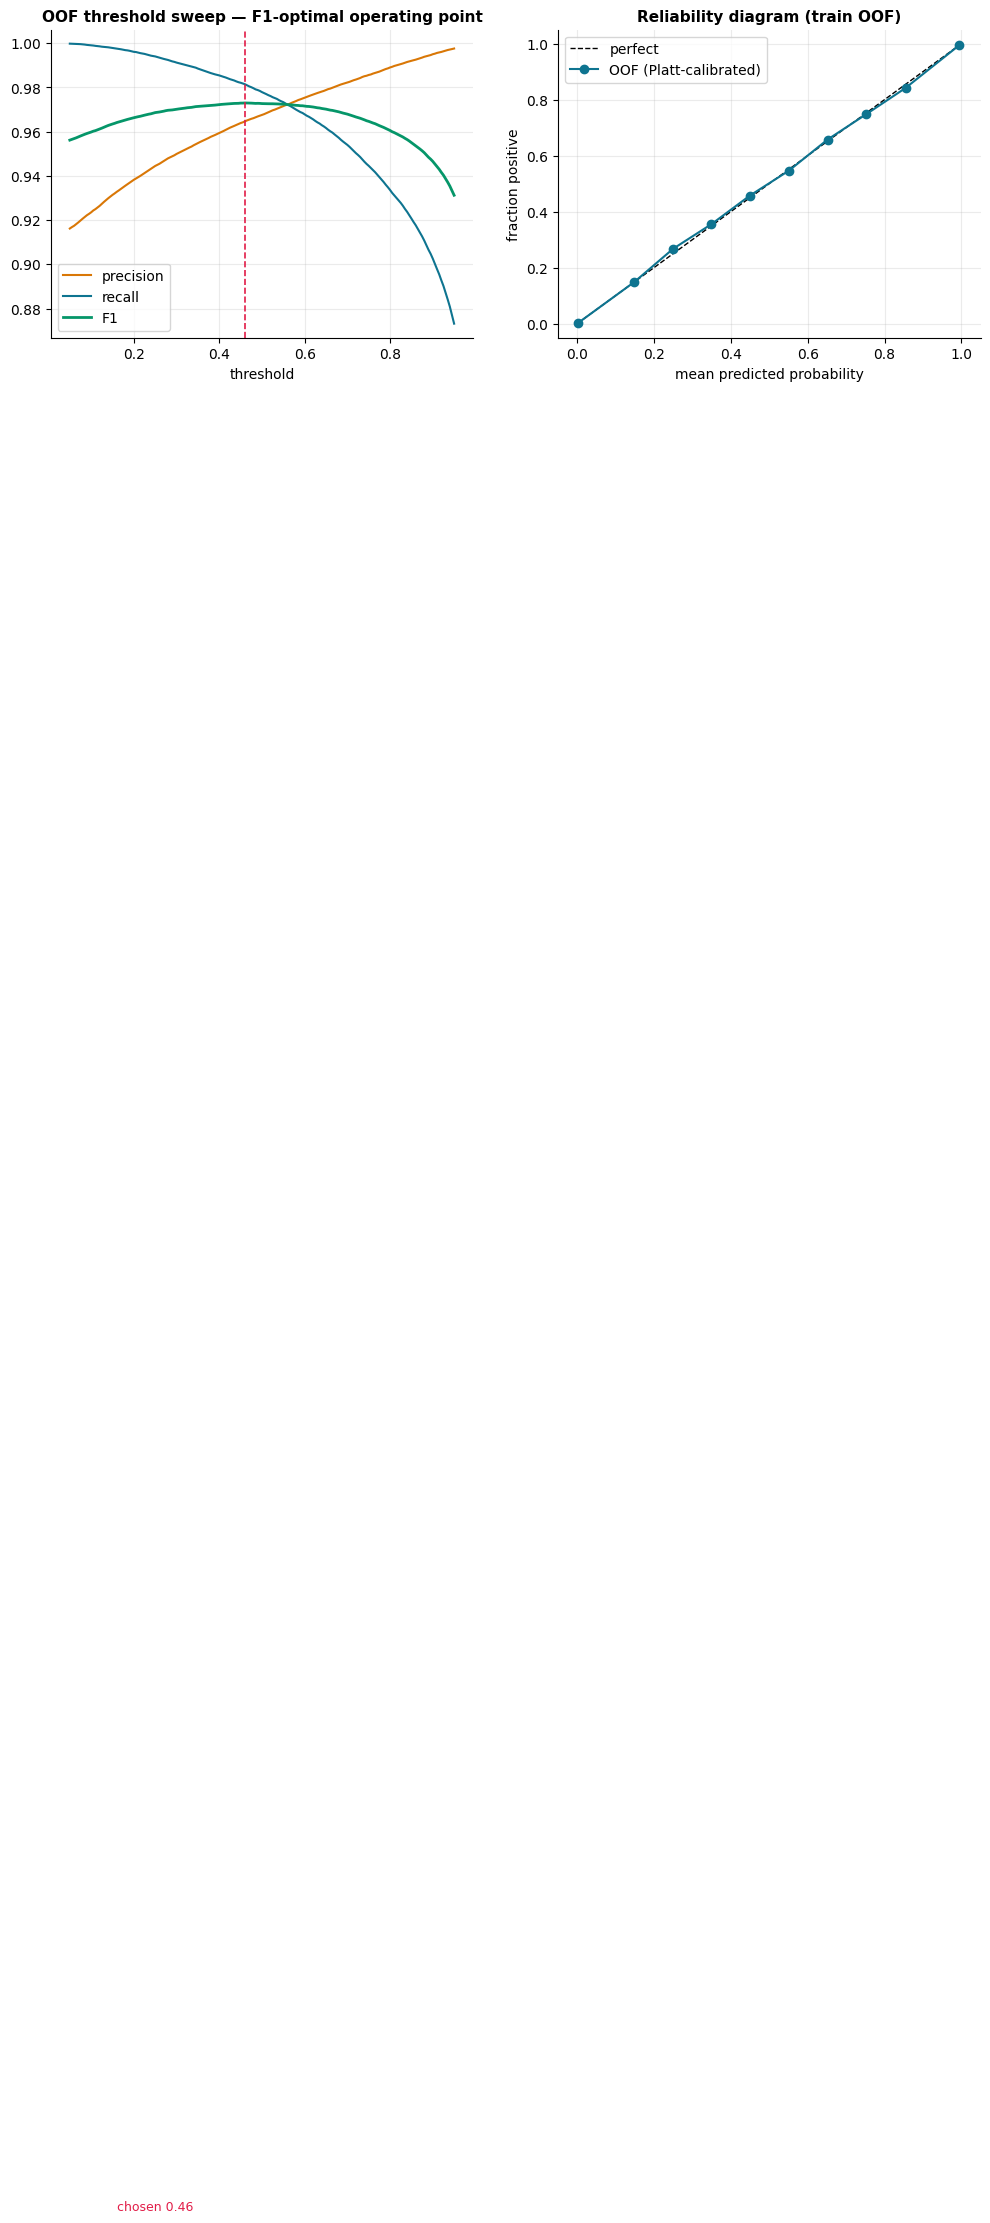

In [25]:
thr_df = pd.DataFrame(calibration["threshold_curve"])
rel_df = pd.DataFrame(calibration["oof_reliability"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thr_df["threshold"], thr_df["precision"], label="precision", color=PAL["warn"])
axes[0].plot(thr_df["threshold"], thr_df["recall"], label="recall", color=PAL["primary"])
axes[0].plot(thr_df["threshold"], thr_df["f1"], label="F1", color=PAL["ok"], lw=2)
axes[0].axvline(best_thr, color=PAL["danger"], ls="--", lw=1.2)
axes[0].annotate(f"chosen {best_thr:.2f}", (best_thr, thr_df["f1"].max()), xytext=(best_thr - 0.3, 0.02),
                 color=PAL["danger"], fontsize=9)
axes[0].set_xlabel("threshold"); axes[0].set_title("OOF threshold sweep — F1-optimal operating point")
axes[0].legend()
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
axes[1].plot(rel_df["mean_predicted"], rel_df["fraction_positive"], "o-", color=PAL["primary"], label="OOF (Platt-calibrated)")
axes[1].set_xlabel("mean predicted probability"); axes[1].set_ylabel("fraction positive")
axes[1].set_title("Reliability diagram (train OOF)")
axes[1].legend()
fig.tight_layout(); plt.show()


## 19 — Final Evaluation on the Official Test Set

The models, calibrators and threshold are now **frozen**; this section scores
the official test set exactly once. Full metric sets, confusion matrices, ROC/
PR curves, anomaly ranking and the operational risk-score distribution are all
produced here — this is the cell whose numbers match the README and the model
cards.

In **verify mode**, the section ends with a cell-by-cell parity check against
the shipped `metrics/test_evaluation.json` (tolerance 1e-6) — the reproduction
proof for this release.


In [26]:
t0 = time.time()
te_bin_logits = bin_final.predict(X_te, raw_score=True)
te_mc_logits = mc_final.predict(X_te, raw_score=True)
infer_ms_10k = (time.time() - t0) / len(X_te) * 10000 * 1000

te_bin_prob = sigmoid(a * te_bin_logits + b)          # Platt-calibrated
te_mc_prob = softmax(te_mc_logits / T)                 # temperature-scaled
te_pred_class = te_mc_prob.argmax(1)
te_anom_raw = iforest_score_serialized(iforest_art["trees"], X_te.astype(np.float64),
                                       iforest_art["c_n"], iforest_art["n_estimators"])
te_anom_norm = np.array([normalize_anomaly(r, iforest_art["norm_anchors"], iforest_art["norm_anchor_targets"])
                         for r in te_anom_raw])
del te_bin_logits, te_mc_logits; gc.collect()
print(f"scored {len(X_te):,} test events | python batch latency {infer_ms_10k:.1f} ms / 10k events (both boosters)")


scored 82,332 test events | python batch latency 2967.4 ms / 10k events (both boosters)


MODEL A — binary attack detector (threshold 0.46):


,value
accuracy,0.8663
precision,0.8124
recall,0.9844
f1,0.8902
roc_auc,0.9826
pr_auc,0.9873
specificity,0.0156
false_positive_rate,0.2785
threshold,0.4600


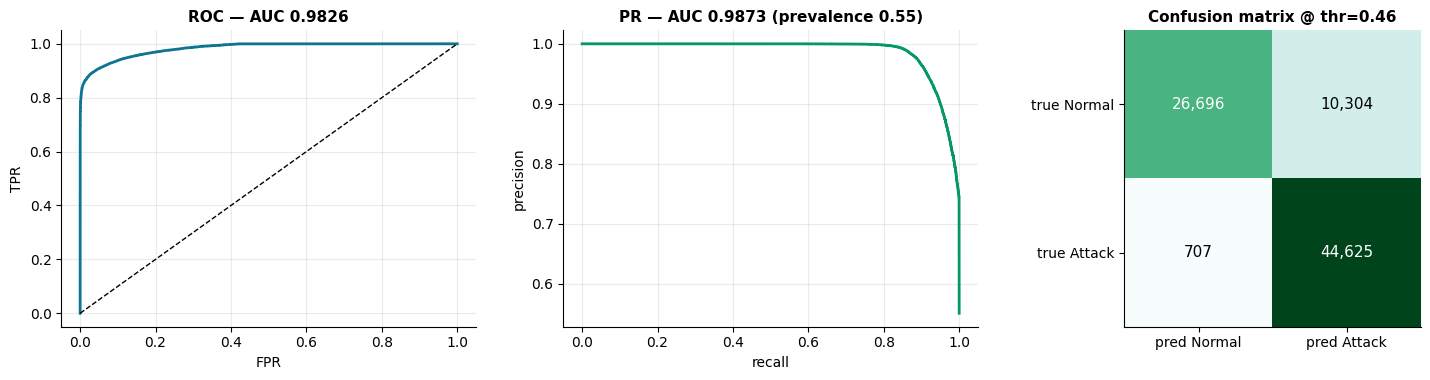

In [27]:
bin_test = binary_metrics(yb_te, te_bin_prob, thr=best_thr)
cm_bin = np.array(bin_test["confusion_matrix"])
print("MODEL A — binary attack detector (threshold %.2f):" % best_thr)
display(pd.DataFrame({k: round(v, 4) for k, v in bin_test.items()
                      if k not in ("confusion_matrix",)} , index=["value"]).T)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
fpr, tpr, _ = roc_curve(yb_te, te_bin_prob)
axes[0].plot(fpr, tpr, color=PAL["primary"], lw=2)
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title(f"ROC — AUC {bin_test['roc_auc']:.4f}")
prec_arr, rec_arr, _ = precision_recall_curve(yb_te, te_bin_prob)
axes[1].plot(rec_arr, prec_arr, color=PAL["ok"], lw=2)
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title(f"PR — AUC {bin_test['pr_auc']:.4f} (prevalence {yb_te.mean():.2f})")
im = axes[2].imshow(cm_bin, cmap="BuGn")
axes[2].set_xticks([0, 1]); axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["pred Normal", "pred Attack"]); axes[2].set_yticklabels(["true Normal", "true Attack"])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f"{cm_bin[i, j]:,}", ha="center", va="center",
                     color="white" if cm_bin[i, j] > cm_bin.max() / 2 else "black", fontsize=11)
axes[2].set_title(f"Confusion matrix @ thr={best_thr:.2f}"); axes[2].grid(False)
fig.tight_layout(); plt.show()


MODEL B — multiclass attack-category classifier:


,value
accuracy,0.7711
macro_precision,0.5585
macro_recall,0.5585
macro_f1,0.5197
weighted_f1,0.7856
balanced_accuracy,0.5585


,support,precision,recall,f1
class,,,,
Analysis,677,0.0551,0.1108,0.0736
Backdoor,583,0.0332,0.0909,0.0486
DoS,4089,0.6239,0.1071,0.1828
Exploits,11132,0.6095,0.8562,0.7121
Fuzzers,6062,0.3194,0.6229,0.4223
Generic,18871,0.9959,0.9720,0.9838
Normal,37000,0.9721,0.7599,0.8530
Reconnaissance,3496,0.9300,0.8095,0.8656
Shellcode,378,0.3792,0.8016,0.5149


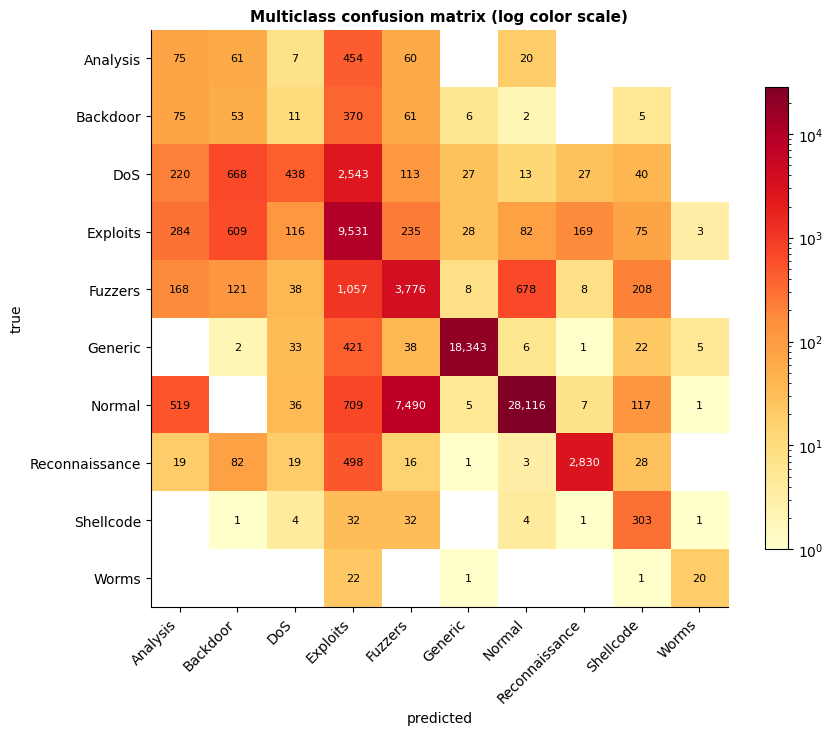

In [28]:
mc_test = multiclass_metrics(ym_te, te_pred_class, te_mc_prob)
print("MODEL B — multiclass attack-category classifier:")
display(pd.DataFrame({k: round(v, 4) for k, v in mc_test.items()
                      if k not in ("per_class", "confusion_matrix", "classes")}, index=["value"]).T)

per_class_df = pd.DataFrame(mc_test["per_class"]).set_index("class")
display(per_class_df.round(4))

cm_mc = np.array(mc_test["confusion_matrix"])
fig, ax = plt.subplots(figsize=(9.5, 7.5))
im = ax.imshow(cm_mc, norm=matplotlib.colors.LogNorm(vmin=1, vmax=cm_mc.max()), cmap="YlOrRd")
ax.set_xticks(range(len(CATS))); ax.set_yticks(range(len(CATS)))
ax.set_xticklabels(CATS, rotation=45, ha="right"); ax.set_yticklabels(CATS)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Multiclass confusion matrix (log color scale)")
for i in range(len(CATS)):
    for j in range(len(CATS)):
        v = cm_mc[i, j]
        if v > 0:
            ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=8,
                    color="black" if v < cm_mc.max() / 30 else "white")
ax.grid(False)
fig.colorbar(im, shrink=0.8)
plt.show()


MODEL C — anomaly detector (trained on NORMAL traffic only):
  ROC-AUC 0.7963 | PR-AUC 0.7949


,K,precision@K,recall@K
0,100,0.9600,0.0021
1,500,0.9780,0.0108
2,1000,0.9810,0.0216
3,5000,0.8846,0.0976


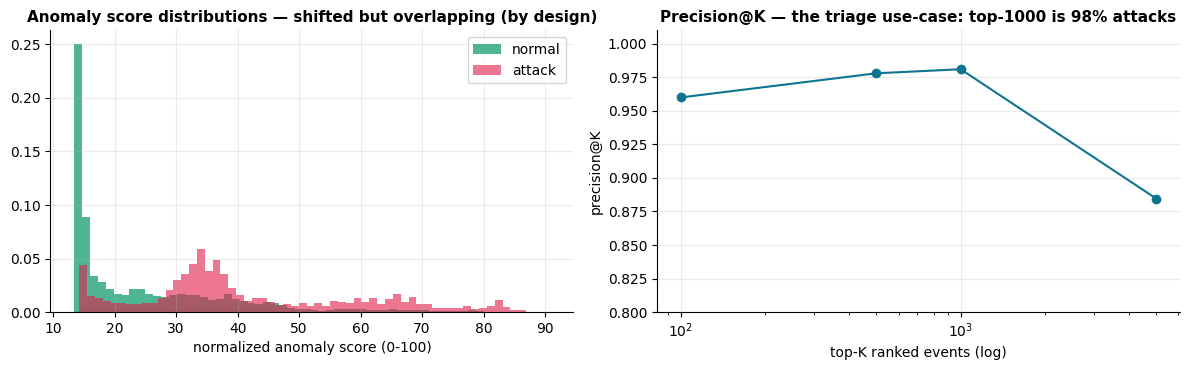

In [29]:
anom_metrics = {
    "roc_auc_vs_label": float(roc_auc_score(yb_te, te_anom_raw)),
    "pr_auc_vs_label": float(average_precision_score(yb_te, te_anom_raw)),
    "score_distribution_normal": {
        "mean": float(te_anom_norm[yb_te == 0].mean()),
        "p50": float(np.percentile(te_anom_norm[yb_te == 0], 50)),
        "p90": float(np.percentile(te_anom_norm[yb_te == 0], 90))},
    "score_distribution_attack": {
        "mean": float(te_anom_norm[yb_te == 1].mean()),
        "p50": float(np.percentile(te_anom_norm[yb_te == 1], 50)),
        "p90": float(np.percentile(te_anom_norm[yb_te == 1], 90))},
}
order_anom = np.argsort(-te_anom_raw)
for k in (100, 500, 1000, 5000):
    hits = int(yb_te[order_anom[:k]].sum())
    anom_metrics[f"precision_at_{k}"] = hits / k
    anom_metrics[f"recall_at_{k}"] = hits / float(yb_te.sum())

pk = pd.DataFrame([{"K": k, "precision@K": anom_metrics[f"precision_at_{k}"],
                    "recall@K": anom_metrics[f"recall_at_{k}"]} for k in (100, 500, 1000, 5000)])
print(f"MODEL C — anomaly detector (trained on NORMAL traffic only):")
print(f"  ROC-AUC {anom_metrics['roc_auc_vs_label']:.4f} | PR-AUC {anom_metrics['pr_auc_vs_label']:.4f}")
display(pk.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].hist(te_anom_norm[yb_te == 0], bins=60, alpha=0.7, label="normal", color=PAL["ok"], density=True)
axes[0].hist(te_anom_norm[yb_te == 1], bins=60, alpha=0.6, label="attack", color=PAL["danger"], density=True)
axes[0].set_xlabel("normalized anomaly score (0-100)"); axes[0].legend()
axes[0].set_title("Anomaly score distributions — shifted but overlapping (by design)")
axes[1].plot(pk["K"], pk["precision@K"], "o-", color=PAL["primary"])
axes[1].set_xscale("log"); axes[1].set_xlabel("top-K ranked events (log)")
axes[1].set_ylabel("precision@K"); axes[1].set_ylim(0.8, 1.01)
axes[1].set_title("Precision@K — the triage use-case: top-1000 is 98% attacks")
fig.tight_layout(); plt.show()


Model D risk score: mean 38.4 | cumulative bands: {'low': 82332, 'medium': 57552, 'high': 34034, 'critical': 0}
worked example: p=0.95, anomaly=70, 'Exploits', 5 related alerts -> risk=73.8 (High)


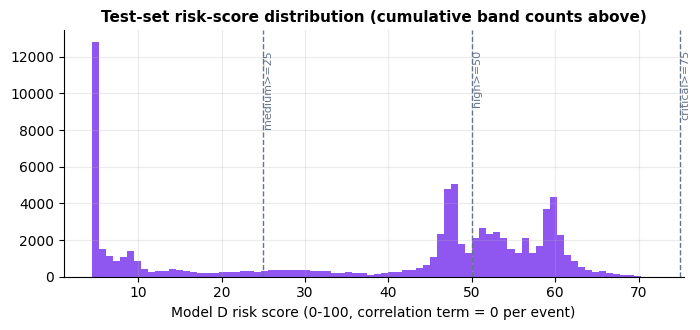

In [30]:
# ------------------------------------------------- Model D: transparent risk scoring
# Weighted formula over the outputs of A/B/C (+ correlation). No learned
# weights — every term is auditable and exported in the model registry.
RISK_CONFIG = {
    "weights": {
        "attack_confidence": 32,
        "anomaly": 18,
        "category_severity": 20,
        "rarity": 8,
        "uncertainty": 10,
        "correlation": 12,
    },
    "category_severity": {
        "Exploits": 1.0, "Shellcode": 0.95, "Worms": 0.9, "Backdoor": 0.85,
        "DoS": 0.8, "Reconnaissance": 0.55, "Analysis": 0.6, "Fuzzers": 0.45,
        "Generic": 0.4, "Normal": 0.05,
    },
    "severity_bands": {"low": 24, "medium": 49, "high": 74},
    "correlation_alert_saturation": 8,
    "uncertainty_formula": "2 * p * (1 - p) * 2  # scaled to [0,1], max at p=0.5",
}

def risk_score(attack_prob, anomaly_norm, category, related_alerts, cfg=RISK_CONFIG):
    w = cfg["weights"]
    sev = cfg["category_severity"].get(category, 0.3)
    prevalence = RARITY.get(category, 0.5)
    rarity = min(1.0, -np.log10(max(prevalence, 1e-6)) / 4.0)
    unc = 2 * attack_prob * (1 - attack_prob) * 2
    corr = min(1.0, related_alerts / cfg["correlation_alert_saturation"])
    risk = (w["attack_confidence"] * attack_prob
            + w["anomaly"] * (anomaly_norm / 100.0)
            + w["category_severity"] * sev
            + w["rarity"] * rarity
            + w["uncertainty"] * unc
            + w["correlation"] * corr)
    return float(min(100.0, max(0.0, risk)))

def severity_band(risk):
    bb = RISK_CONFIG["severity_bands"]
    if risk <= bb["low"]: return "Low"
    if risk <= bb["medium"]: return "Medium"
    if risk <= bb["high"]: return "High"
    return "Critical"

te_pred_cat = np.where(te_bin_prob >= best_thr, te_pred_class, CAT_TO_IDX["Normal"])
te_risk = np.array([risk_score(te_bin_prob[i], te_anom_norm[i], CATS[c], 0)
                    for i, c in enumerate(te_pred_cat)])

risk_dist = {
    "mean": float(te_risk.mean()),
    "bands": {b: int((te_risk >= lo).sum()) for b, lo in
              [("low", 0), ("medium", 25), ("high", 50), ("critical", 75)]},
}
test_calibration = {
    "reliability": reliability_curve(yb_te, te_bin_prob),
    "brier": float(brier_score_loss(yb_te, te_bin_prob)),
    "risk_distribution": risk_dist,
}
eval_test = {
    "binary": bin_test, "multiclass": mc_test, "anomaly": anom_metrics,
    "calibration": test_calibration,
    "note": "Official UNSW-NB15 test set, scored exactly once after model freeze.",
}
if RUN_TRAINING:
    jdump(eval_test, ART / "metrics" / "test_evaluation.json")
    print("exported metrics/test_evaluation.json")

print(f"Model D risk score: mean {risk_dist['mean']:.1f} | cumulative bands: {risk_dist['bands']}")
print(f"worked example: p=0.95, anomaly=70, 'Exploits', 5 related alerts -> "
      f"risk={risk_score(0.95, 70, 'Exploits', 5):.1f} ({severity_band(risk_score(0.95, 70, 'Exploits', 5))})")

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(te_risk, bins=80, color=PAL["accent"], alpha=0.85)
for lo, lab in [(25, "medium>=25"), (50, "high>=50"), (75, "critical>=75")]:
    ax.axvline(lo, color=PAL["muted"], ls="--", lw=1)
    ax.text(lo, ax.get_ylim()[1] * 0.92, lab, rotation=90, fontsize=8, color=PAL["muted"], va="top")
ax.set_xlabel("Model D risk score (0-100, correlation term = 0 per event)")
ax.set_title("Test-set risk-score distribution (cumulative band counts above)")
plt.show()


In [31]:
if not RUN_TRAINING:
    stored_eval = json.load(open(ART / "metrics" / "test_evaluation.json"))
    checks = []
    for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "specificity", "false_positive_rate"]:
        checks.append((f"binary.{k}", stored_eval["binary"][k], bin_test[k]))
    for k in ["accuracy", "macro_f1", "weighted_f1", "balanced_accuracy", "macro_precision", "macro_recall"]:
        checks.append((f"multiclass.{k}", stored_eval["multiclass"][k], mc_test[k]))
    for k in ["roc_auc_vs_label", "precision_at_100", "precision_at_1000"]:
        checks.append((f"anomaly.{k}", stored_eval["anomaly"][k], anom_metrics[k]))
    checks.append(("binary.confusion_matrix", stored_eval["binary"]["confusion_matrix"], bin_test["confusion_matrix"]))
    checks.append(("multiclass.confusion_matrix", stored_eval["multiclass"]["confusion_matrix"], mc_test["confusion_matrix"]))
    par = pd.DataFrame([{"metric": n, "shipped": (s if isinstance(s, list) else round(s, 6)),
                         "recomputed": (r if isinstance(r, list) else round(r, 6)),
                         "delta": (0 if isinstance(s, list) else abs(s - r))}
                        for n, s, r in checks])
    max_delta = par["delta"].max()
    display(par)
    print(f"max |delta| across {len(checks)} checks: {max_delta:.2e}")
    assert max_delta < 1e-6, "REPRODUCTION MISMATCH — investigate before trusting artifacts"
    print("VERIFY: official test evaluation reproduces the shipped metrics EXACTLY")
else:
    print("train mode: test_evaluation.json was written — the shipped numbers were generated by this cell")


,metric,shipped,recomputed,delta
0,binary.accuracy,0.866261,0.866261,0.0
1,binary.precision,0.812412,0.812412,0.0
2,binary.recall,0.984404,0.984404,0.0
3,binary.f1,0.890177,0.890177,0.0
4,binary.roc_auc,0.982623,0.982623,0.0
5,binary.pr_auc,0.987272,0.987272,0.0
6,binary.specificity,0.015596,0.015596,0.0
7,binary.false_positive_rate,0.278486,0.278486,0.0
8,multiclass.accuracy,0.771085,0.771085,0.0
9,multiclass.macro_f1,0.519727,0.519727,0.0


max |delta| across 19 checks: 0.00e+00
VERIFY: official test evaluation reproduces the shipped metrics EXACTLY


## 20 — SHAP / Explainability

Explainability is a product feature, not an afterthought: the SOC UI renders
global feature importance and per-event attributions directly from these
artifacts.

* **Global importance — exact TreeSHAP** (`shap.TreeExplainer`) on the binary
  model over a 2,000-row training sample. In *train mode* this becomes
  `metrics/shap_global.json`; in *verify mode* the recomputed ranking is
  compared against the shipped artifact (top-10 overlap + rank correlation —
  exact value equality is not expected because the 2,000-row sample of the
  original run came from a differently-consumed RNG stream; the *ordering* is
  what must be stable).
* **Multiclass** importance uses LightGBM's native split-gain.
* **Local explanations** use LightGBM's exact `pred_contrib` (TreeSHAP)
  values — the notebook shows one worked event; the production engine serves
  pre-computed exact attributions for replay events and falls back to Saabas
  path attributions (verified to satisfy baseline + Σcontribs = raw score)
  for arbitrary live events.


VERIFY: global SHAP top-10 overlap with shipped artifact: 10/10 (Spearman rho over all 54 features = 0.9992)
  (exact values differ by design: the 2000-row sample is drawn from a fresh RNG stream)


/home/z/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


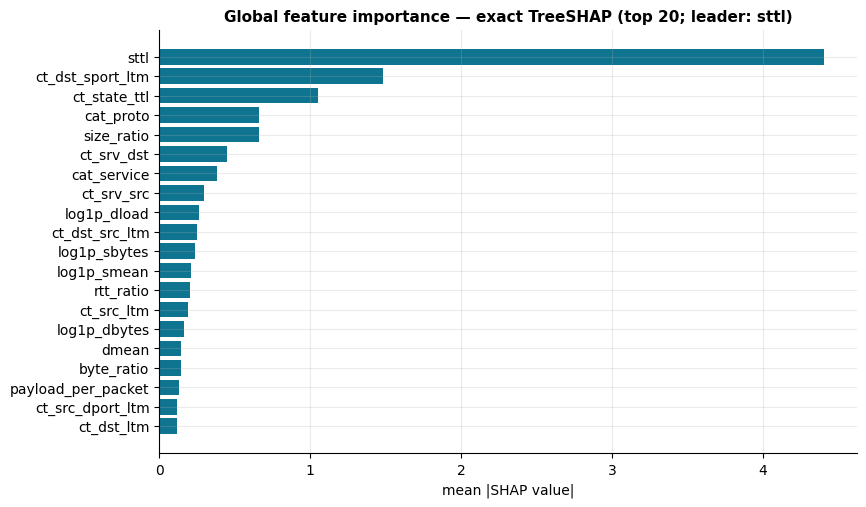

top 5: [('sttl', 4.402), ('ct_dst_sport_ltm', 1.484), ('ct_state_ttl', 1.051), ('cat_proto', 0.66), ('size_ratio', 0.66)]


In [32]:
expl = shap.TreeExplainer(bin_final)
sh_idx = rng.choice(len(X_tr), size=2000, replace=False)
sv = expl.shap_values(X_tr[sh_idx].astype(np.float64))
if isinstance(sv, list):
    sv = sv[1]
mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(-mean_abs)
shap_global = {
    "expected_value": float(expl.expected_value) if np.isscalar(expl.expected_value) else float(expl.expected_value[0]),
    "method": "TreeSHAP (exact), shap.TreeExplainer on LightGBM binary model, 2000-row training sample",
    "features": [{"feature": feat_names[i], "mean_abs_shap": float(mean_abs[i])} for i in order],
}
if RUN_TRAINING:
    jdump(shap_global, ART / "metrics" / "shap_global.json")
    print("exported metrics/shap_global.json")
else:
    stored_shap = json.load(open(ART / "metrics" / "shap_global.json"))
    stored_top10 = [f["feature"] for f in stored_shap["features"][:10]]
    new_top10 = [feat_names[i] for i in order[:10]]
    overlap = len(set(stored_top10) & set(new_top10))
    from scipy.stats import spearmanr
    sv_map = {f["feature"]: f["mean_abs_shap"] for f in stored_shap["features"]}
    nv_map = {feat_names[i]: float(mean_abs[i]) for i in range(len(feat_names))}
    rho = spearmanr([sv_map[f] for f in feat_names], [nv_map[f] for f in feat_names]).statistic
    print(f"VERIFY: global SHAP top-10 overlap with shipped artifact: {overlap}/10 "
          f"(Spearman rho over all {len(feat_names)} features = {rho:.4f})")
    print("  (exact values differ by design: the 2000-row sample is drawn from a fresh RNG stream)")

top20 = shap_global["features"][:20]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh([f["feature"] for f in top20][::-1], [f["mean_abs_shap"] for f in top20][::-1], color=PAL["primary"])
ax.set_xlabel("mean |SHAP value|")
ax.set_title(f"Global feature importance — exact TreeSHAP (top 20; leader: {top20[0]['feature']})")
plt.show()
print(f"top 5: {[(f['feature'], round(f['mean_abs_shap'], 3)) for f in top20[:5]]}")


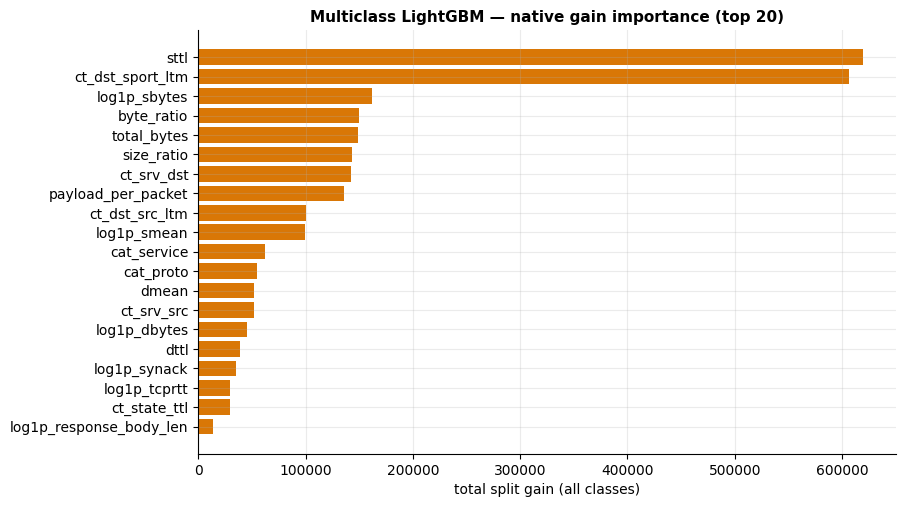

In [33]:
mc_gain = mc_final.feature_importance("gain")
mc_order = np.argsort(-mc_gain)
mc_gain_art = {"features": [{"feature": feat_names[i], "gain": float(mc_gain[i])} for i in mc_order]}
if RUN_TRAINING:
    jdump(mc_gain_art, ART / "metrics" / "multiclass_gain.json")
    print("exported metrics/multiclass_gain.json")

top20g = mc_gain_art["features"][:20]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh([f["feature"] for f in top20g][::-1], [f["gain"] for f in top20g][::-1], color=PAL["warn"])
ax.set_xlabel("total split gain (all classes)")
ax.set_title("Multiclass LightGBM — native gain importance (top 20)")
plt.show()


event row 6490 | true category: Reconnaissance | calibrated P(attack)=0.9999
SHAP baseline (expected value): +3.3045


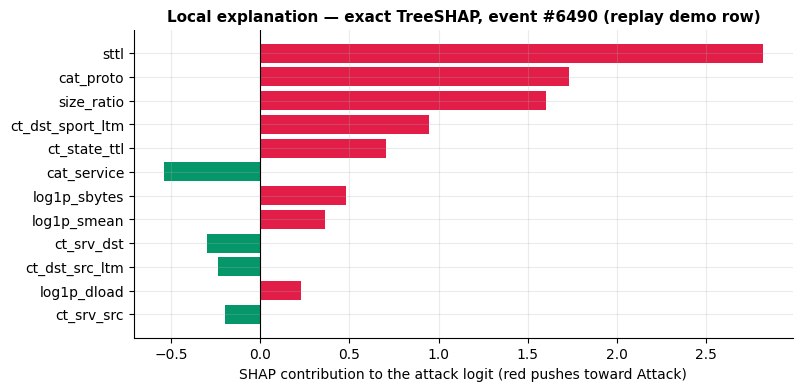

In [34]:
# local explanation — one worked example on a real test attack event
demo_seq = json.load(open(ART / "replay" / "demo_sequence.json"))
demo_idx = [e["i"] for e in demo_seq["events"]]
example_rows = [i for i in demo_idx if test_label_arr[i] == 1][:1]
i_ex = example_rows[0]
X_ex = fb.transform(test.iloc[[i_ex]]).astype(np.float32)
contribs = bin_final.predict(X_ex, pred_contrib=True)[0]   # exact TreeSHAP (features + bias)
pairs = sorted(zip(feat_names, contribs[:-1]), key=lambda kv: -abs(kv[1]))[:12]
print(f"event row {i_ex} | true category: {test.iloc[i_ex]['attack_cat']} | "
      f"calibrated P(attack)={sigmoid(a * float(bin_final.predict(X_ex, raw_score=True)[0]) + b):.4f}")
print(f"SHAP baseline (expected value): {contribs[-1]:+.4f}")

fig, ax = plt.subplots(figsize=(8.5, 4))
names = [p[0] for p in pairs][::-1]; vals = [p[1] for p in pairs][::-1]
ax.barh(names, vals, color=[PAL["danger"] if v > 0 else PAL["ok"] for v in vals])
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("SHAP contribution to the attack logit (red pushes toward Attack)")
ax.set_title(f"Local explanation — exact TreeSHAP, event #{i_ex} (replay demo row)")
plt.show()
del X_ex, contribs


## 21 — Error Analysis

Where does the system still fail, concretely?

**Binary (A).** The F1-optimal threshold 0.46 buys recall 0.984 at the cost of
specificity 0.016 — i.e. **27.9% of benign test traffic is alerted**. For a
SOC triage layer with correlation (which groups false positives into few
incidents) this is a deliberate trade, but it is reported here without
cosmetics: an analyst should know ~1 in 4 alerts on *pure* flows is noise
before correlation.

**Multiclass (B).** The dominant failure mode is **DoS → Exploits** (~2.5k
events) — both are "high-volume service abuse" families sharing statistical
footprints — plus chronic confusion inside the rare classes (§22). The
confusion heat map in §19 visualises the full matrix; below we rank the top
confused pairs and inspect the highest-confidence binary false positives.


binary false positives: 10,304 / 37,000 benign  (FPR 27.8%)
binary false negatives: 707 / 45,332 attacks (miss rate 1.6%)
highest-confidence FALSE POSITIVES (benign flows the model is most sure about):


,dur,proto,service,state,sbytes,rate,sttl,attack_cat,p_attack
41107,0.000005,udp,-,INT,256,200000.005100,254,Normal,0.9994
68084,0.608410,tcp,-,FIN,1124,34.516198,254,Normal,0.9991
68085,0.381009,tcp,-,FIN,1126,49.867587,254,Normal,0.9989
67415,7.826361,udp,radius,INT,3808,0.894413,254,Normal,0.9987
81268,0.337419,tcp,-,FIN,1130,56.309810,254,Normal,0.9986


top-10 confused category pairs:


true,Normal,DoS,Fuzzers,Normal,Fuzzers,DoS,Exploits,Normal,Reconnaissance,Analysis
predicted,Fuzzers,Exploits,Exploits,Exploits,Normal,Backdoor,Backdoor,Analysis,Exploits,Exploits
events,7490,2543,1057,709,678,668,609,519,498,454


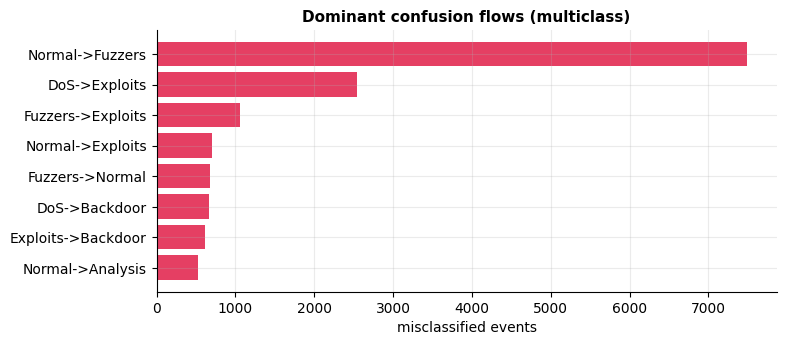

In [35]:
fp_mask = (te_bin_prob >= best_thr) & (yb_te == 0)
fn_mask = (te_bin_prob < best_thr) & (yb_te == 1)
print(f"binary false positives: {fp_mask.sum():,} / {(yb_te == 0).sum():,} benign  (FPR {bin_test['false_positive_rate']:.1%})")
print(f"binary false negatives: {fn_mask.sum():,} / {(yb_te == 1).sum():,} attacks (miss rate {1 - bin_test['recall']:.1%})")

hi_fp = np.argsort(-np.where(fp_mask, te_bin_prob, -1))[:5]
cols_show = ["dur", "proto", "service", "state", "sbytes", "rate", "sttl", "attack_cat"]
print("highest-confidence FALSE POSITIVES (benign flows the model is most sure about):")
display(test.iloc[hi_fp][cols_show].assign(p_attack=np.round(te_bin_prob[hi_fp], 4)))

cm_mc_arr = np.array(mc_test["confusion_matrix"])
pairs_err = []
for i in range(len(CATS)):
    for j in range(len(CATS)):
        if i != j and cm_mc_arr[i, j] > 0:
            pairs_err.append((CATS[i], CATS[j], int(cm_mc_arr[i, j])))
pairs_err.sort(key=lambda t: -t[2])
err_df = pd.DataFrame(pairs_err[:10], columns=["true", "predicted", "events"]).set_index(["true", "predicted"])
print("top-10 confused category pairs:")
display(err_df.T)

fig, ax = plt.subplots(figsize=(8, 3.4))
top = pairs_err[:8]
ax.barh([f"{t}->{p}" for t, p, _ in top][::-1], [n for _, _, n in top][::-1], color=PAL["danger"], alpha=0.85)
ax.set_xlabel("misclassified events")
ax.set_title("Dominant confusion flows (multiclass)")
plt.show()


## 22 — Rare-Class Analysis

Rare attack categories are the honest failure surface of this dataset: with
174 `Worms` training rows (0.1% of train) no model learns a reliable Worms
signature. The plot below shows per-class F1 against support — the
approximately monotonic relationship is the textbook imbalance story. Note
that:

* the **balanced** objective rescues recall on mid-rare classes (Backdoor,
  Analysis reach usable recall at low precision) — without it macro-F1
  collapses to ~0.32;
* `Worms` (test support 44) and `Shellcode` remain effectively undetectable —
  events leak into `Exploits`/`Generic`;
* Layer C partially compensates: anomalies that B misclassifies still carry
  elevated anomaly scores, so the *risk score* (Model D) ranks many of them
  into High/Critical bands anyway.

This is a *documented limitation*, not a hidden one: the SOC UI labels
rare-category verdicts with the same epistemics badges as everything else.


,train_support,support,prevalence_train,precision,recall,f1
class,,,,,,
Analysis,2000,677,0.0114,0.0551,0.1108,0.0736
Backdoor,1746,583,0.0100,0.0332,0.0909,0.0486
DoS,12264,4089,0.0699,0.6239,0.1071,0.1828
Exploits,33393,11132,0.1904,0.6095,0.8562,0.7121
Fuzzers,18184,6062,0.1037,0.3194,0.6229,0.4223
Generic,40000,18871,0.2281,0.9959,0.9720,0.9838
Normal,56000,37000,0.3194,0.9721,0.7599,0.8530
Reconnaissance,10491,3496,0.0598,0.9300,0.8095,0.8656
Shellcode,1133,378,0.0065,0.3792,0.8016,0.5149


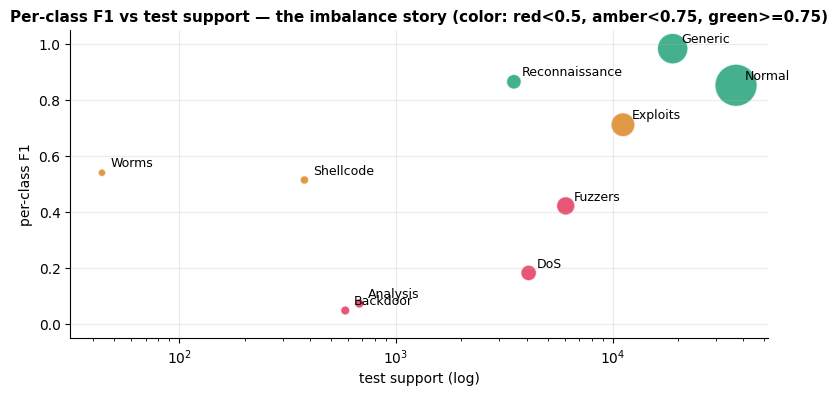

best classes : Generic (F1 0.98), Reconnaissance (F1 0.87), Normal (F1 0.85)
worst classes: Backdoor (F1 0.05), Analysis (F1 0.07), DoS (F1 0.18)


In [36]:
pc = per_class_df.copy()
pc["train_support"] = [int((train["attack_cat"] == c).sum()) for c in pc.index]
pc["prevalence_train"] = [RARITY[c] for c in pc.index]
display(pc[["train_support", "support", "prevalence_train", "precision", "recall", "f1"]].round(4))

fig, ax = plt.subplots(figsize=(9, 4))
sizes = 30 + 900 * (pc["support"] / pc["support"].max())
colors = [PAL["danger"] if f < 0.5 else (PAL["warn"] if f < 0.75 else PAL["ok"]) for f in pc["f1"]]
ax.scatter(pc["support"], pc["f1"], s=sizes, c=colors, alpha=0.75, edgecolors="white")
for c, row in pc.iterrows():
    ax.annotate(c, (row["support"], row["f1"]), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("test support (log)")
ax.set_ylabel("per-class F1"); ax.set_ylim(-0.05, 1.05)
ax.set_title("Per-class F1 vs test support — the imbalance story (color: red<0.5, amber<0.75, green>=0.75)")
plt.show()

best3 = pc.sort_values("f1", ascending=False).head(3)
worst3 = pc.sort_values("f1").head(3)
print("best classes :", ", ".join(f"{i} (F1 {r:.2f})" for i, r in best3["f1"].items()))
print("worst classes:", ", ".join(f"{i} (F1 {r:.2f})" for i, r in worst3["f1"].items()))


## 23 — Operational Metrics

Numbers a platform team cares about: batch latency (Python reference), model
sizes, and artifact footprint. The production **TypeScript** engine (which
walks the same trees in-process) sustains ~640 events/s at boot including
correlation and ~1.7 ms per single live event — measured during QA on the
reference machine and recorded in `docs/QA_REPORT.md`.


In [37]:
t0 = time.time()
_ = bin_final.predict(X_te[:10000], raw_score=True)
_ = mc_final.predict(X_te[:10000], raw_score=True)
elapsed = time.time() - t0   # seconds for 10k events through BOTH boosters
operational = {
    "python_batch_ms_per_10k_events": round(elapsed * 1000, 1),
    "python_single_event_ms": round(elapsed / 10000 * 1000, 3),
    "total_notebook_seconds": round(time.time() - T_NOTEBOOK, 1),
}
print(f"python reference: {operational['python_single_event_ms']:.3f} ms/event "
      f"({operational['python_batch_ms_per_10k_events']:.1f} ms / 10k events, both boosters)")

sizes = pd.DataFrame([
    {"artifact": "models/binary_lightgbm.txt", "MB": round((ART / "models" / "binary_lightgbm.txt").stat().st_size / 1e6, 1)},
    {"artifact": "models/multiclass_lightgbm.txt", "MB": round((ART / "models" / "multiclass_lightgbm.txt").stat().st_size / 1e6, 1)},
    {"artifact": "models/binary_lightgbm.json (engine)", "MB": round((ART / "models" / "binary_lightgbm.json").stat().st_size / 1e6, 1)},
    {"artifact": "models/multiclass_lightgbm.json (engine)", "MB": round((ART / "models" / "multiclass_lightgbm.json").stat().st_size / 1e6, 1)},
    {"artifact": "models/isolation_forest.json", "MB": round((ART / "models" / "isolation_forest.json").stat().st_size / 1e6, 1)},
    {"artifact": "explainability/shap_cache.json", "MB": round((ART / "explainability" / "shap_cache.json").stat().st_size / 1e6, 1)},
    {"artifact": "preprocessor/ (feature_config + clustering)", "MB": round(((ART / "preprocessor" / "feature_config.json").stat().st_size + (ART / "preprocessor" / "clustering.json").stat().st_size) / 1e6, 1)},
])
display(sizes)


python reference: 0.330 ms/event (3302.4 ms / 10k events, both boosters)


,artifact,MB
0,models/binary_lightgbm.txt,9.0
1,models/multiclass_lightgbm.txt,7.0
2,models/binary_lightgbm.json (engine),74.3
3,models/multiclass_lightgbm.json (engine),54.7
4,models/isolation_forest.json,2.7
5,explainability/shap_cache.json,2.3
6,preprocessor/ (feature_config + clustering),0.3


## 24 — Model Artifact Export

Everything the production application needs is exported under `ml/artifacts/`
— the application **never retrains** and never invokes Python at runtime:

```
ml/artifacts/
├── models/            binary + multiclass LightGBM (native .txt AND .json tree dump), isolation forest
├── preprocessor/      feature_config.json (the pipeline contract), clustering.json (KMeans+PCA)
├── explainability/    shap_cache.json (exact local attributions for replay/boot events)
├── replay/            demo_sequence.json (deterministic 903-event SOC demo), boot_sample.json (12k stratified)
├── metrics/           comparison, ablation, calibration, test_evaluation, shap_global, ...
├── reports/           eval_summary.json, notebook_verification.json (verify runs)
└── metadata/          model_registry.json (versions, params, threshold, risk config)
```

The **demo replay sequence** is deterministic (seed 42): 903 real test rows
selected per category in escalating waves (background → recon → exploit →
DoS), with **clearly-labelled synthetic timestamps** (the dataset has none —
§04). The **SHAP cache** pre-computes exact TreeSHAP attributions for every
demo + sampled boot event so the UI's local explanations are instant and
exact.

*Train mode* writes all of the above. *Verify mode* checks that every shipped
artifact exists and writes only `reports/notebook_verification.json`.


In [38]:
if RUN_TRAINING:
    # ---------------- deterministic demo replay sequence (seed 42) ----------------
    rng2 = np.random.RandomState(SEED)
    test_idx_by_cat = {c: test.index[test["attack_cat"] == c].to_numpy() for c in CATS}

    def pick(cat, n):
        pool = test_idx_by_cat[cat]
        n = min(n, len(pool))
        sel = rng2.choice(pool, size=n, replace=False)
        test_idx_by_cat[cat] = np.setdiff1d(pool, sel)
        return sel.tolist()

    events = []
    events += [(i, "background") for i in pick("Normal", 140)]
    events += [(i, "campaign1-recon") for i in pick("Reconnaissance", 26)]
    events += [(i, "background") for i in pick("Normal", 110)]
    events += [(i, "noise") for i in pick("Fuzzers", 14)]
    events += [(i, "background") for i in pick("Normal", 60)]
    events += [(i, "campaign2-exploit") for i in pick("Exploits", 42)]
    events += [(i, "campaign2-exploit") for i in pick("Shellcode", 8)]
    events += [(i, "background") for i in pick("Normal", 90)]
    events += [(i, "noise") for i in pick("Analysis", 8)]
    events += [(i, "noise") for i in pick("Backdoor", 8)]
    events += [(i, "background") for i in pick("Normal", 70)]
    events += [(i, "campaign3-dos") for i in pick("DoS", 55)]
    events += [(i, "campaign3-dos") for i in pick("Generic", 28)]
    events += [(i, "noise") for i in pick("Worms", 4)]
    events += [(i, "background") for i in pick("Normal", 130)]
    events += [(i, "noise") for i in pick("Exploits", 10)]
    events += [(i, "background") for i in pick("Normal", 100)]

    tcur = 0.0
    seq = []
    for idx, wave in events:
        tcur += float(rng2.uniform(90, 260)) if wave == "background" else float(rng2.uniform(15, 55))
        seq.append({"i": int(idx), "t": int(tcur), "wave": wave})
    demo = {
        "label": "Real-Time Detection Replay (SIMULATED timestamps)",
        "simulation_note": "Event times are synthetic replay offsets; the events themselves are real UNSW-NB15 test rows scored by the real trained models.",
        "events": seq,
        "waves": ["background", "campaign1-recon", "noise", "campaign2-exploit", "campaign3-dos"],
        "default_speed_events_per_sec": 8,
        "total_events": len(seq),
        "duration_ms": int(tcur),
    }
    jdump(demo, ART / "replay" / "demo_sequence.json")

    # ---------------- stratified boot sample (command-center state) ----------------
    cat_counts = {c: int((test["attack_cat"] == c).sum()) for c in CATS}
    n_total = len(test)
    boot_idx = []
    for c in CATS:
        pool = test_idx_by_cat[c]
        n = min(len(pool), int(round((cat_counts[c] / n_total) * 12000)))
        boot_idx += rng2.choice(pool, size=n, replace=False).tolist()
    rng2.shuffle(boot_idx)
    jdump({"indices": [int(i) for i in boot_idx],
           "note": "stratified sample of official test set for SOC boot state; scored live by the inference engine"},
          ART / "replay" / "boot_sample.json")

    # ---------------- exact SHAP cache for demo + boot attack rows ----------------
    demo_rows = [e["i"] for e in seq]
    boot_attacks = [i for i in boot_idx if test_label_arr[i] == 1]
    keep_boot = rng2.choice(boot_attacks, size=min(3500, len(boot_attacks)), replace=False).tolist()
    cache_rows = sorted(set(demo_rows + keep_boot))
    Xc = fb.transform(test.iloc[cache_rows]).astype(np.float32)
    contribs_all = bin_final.predict(Xc, pred_contrib=True)
    shap_cache = {}
    for r, row in enumerate(cache_rows):
        shap_cache[str(int(row))] = {"b": [round(float(v), 5) for v in contribs_all[r]]}
    del contribs_all, Xc; gc.collect()
    Xd = fb.transform(test.iloc[demo_rows]).astype(np.float32)
    mc_c = np.asarray(mc_final.predict(Xd, pred_contrib=True))
    mc_contribs = mc_c.reshape(len(demo_rows), len(CATS), len(feat_names) + 1)
    for r, row in enumerate(demo_rows):
        cls = int(te_pred_class[row])
        vec = mc_contribs[r, cls, :-1]
        top_pairs = sorted(zip(feat_names, vec), key=lambda kv: -abs(kv[1]))[:10]
        shap_cache[str(int(row))]["mc"] = {"class": CATS[cls], "top": [[f, round(float(v), 5)] for f, v in top_pairs]}
    del mc_contribs, Xd; gc.collect()
    jdump(shap_cache, ART / "explainability" / "shap_cache.json")

    jdump(dataset_report, ART / "metrics" / "dataset_profile.json")
    jdump(RARITY, ART / "metrics" / "train_prevalence.json")
    print(f"exported replay/demo_sequence.json ({demo['total_events']} events), "
          f"replay/boot_sample.json ({len(boot_idx):,} rows), explainability/shap_cache.json ({len(shap_cache):,} events), "
          f"metrics/dataset_profile.json, metrics/train_prevalence.json")
else:
    demo = json.load(open(ART / "replay" / "demo_sequence.json"))
    boot = json.load(open(ART / "replay" / "boot_sample.json"))
    cache_n = len(json.load(open(ART / "explainability" / "shap_cache.json")))
    wave_counts = pd.Series([e["wave"] for e in demo["events"]]).value_counts()
    print(f"shipped demo_sequence: {demo['total_events']} events | waves: {dict(wave_counts)}")
    print(f"shipped boot_sample  : {len(boot['indices']):,} stratified test rows")
    print(f"shipped shap_cache   : {cache_n:,} events with exact TreeSHAP attributions")


shipped demo_sequence: 903 events | waves: {'background': np.int64(700), 'campaign3-dos': np.int64(83), 'campaign2-exploit': np.int64(50), 'noise': np.int64(44), 'campaign1-recon': np.int64(26)}
shipped boot_sample  : 12,001 stratified test rows
shipped shap_cache   : 4,403 events with exact TreeSHAP attributions


In [39]:
# canonical artifact inventory — must all exist in EITHER mode
canonical = [
    "models/binary_lightgbm.txt", "models/binary_lightgbm.json",
    "models/multiclass_lightgbm.txt", "models/multiclass_lightgbm.json",
    "models/isolation_forest.json",
    "preprocessor/feature_config.json", "preprocessor/clustering.json",
    "explainability/shap_cache.json",
    "replay/demo_sequence.json", "replay/boot_sample.json",
    "metrics/model_comparison.json", "metrics/feature_ablation.json",
    "metrics/calibration.json", "metrics/test_evaluation.json",
    "metrics/shap_global.json", "metrics/multiclass_gain.json",
    "metrics/operational.json", "metrics/dataset_profile.json",
    "metrics/train_prevalence.json",
    "reports/eval_summary.json",
    "metadata/model_registry.json",
]
inv = pd.DataFrame([{"artifact": p, "exists": (ART / p).exists(),
                     "KB": round((ART / p).stat().st_size / 1024, 1) if (ART / p).exists() else None}
                   for p in canonical])
assert inv["exists"].all(), f"missing artifacts: {inv[~inv['exists']]['artifact'].tolist()}"
display(inv)

if not RUN_TRAINING:
    verification = {
        "mode": "verify",
        "executed_at": time.strftime("%Y-%m-%dT%H:%M:%S%z"),
        "models": "loaded from shipped native .txt files (no retraining)",
        "feature_pipeline": "re-fitted on training CSV — reproduces shipped feature_config.json exactly",
        "logistic_baseline": {"f1": lr_row["f1"], "roc_auc": lr_row["roc_auc"]},
        "test_metrics_binary": {k: bin_test[k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "specificity", "false_positive_rate"]},
        "test_metrics_multiclass": {k: mc_test[k] for k in ["accuracy", "macro_f1", "weighted_f1", "balanced_accuracy"]},
        "test_metrics_anomaly": {k: anom_metrics[k] for k in ["roc_auc_vs_label", "precision_at_1000"]},
        "parity_max_abs_delta": float(max_delta),
        "artifacts_verified": canonical,
    }
    jdump(verification, ART / "reports" / "notebook_verification.json")
    print("wrote reports/notebook_verification.json")
else:
    print("train mode: full artifact set exported — see registry in §25")


,artifact,exists,KB
0,models/binary_lightgbm.txt,True,8779.7
1,models/binary_lightgbm.json,True,72577.9
2,models/multiclass_lightgbm.txt,True,6828.2
3,models/multiclass_lightgbm.json,True,53407.3
4,models/isolation_forest.json,True,2685.2
5,preprocessor/feature_config.json,True,7.1
6,preprocessor/clustering.json,True,320.4
7,explainability/shap_cache.json,True,2265.1
8,replay/demo_sequence.json,True,68.0
9,replay/boot_sample.json,True,127.5


wrote reports/notebook_verification.json


## 25 — Model Registry Metadata

`metadata/model_registry.json` is the single machine-readable record of *what
was trained, how, and with what results* — the production engine reads its
threshold, Platt constants, temperature, risk configuration and class mapping
at boot, and the SOC UI displays its version badge. In verify mode the loaded
registry is cross-checked against the calibration artifact and the recomputed
evaluation to prove internal consistency of the shipped release.


In [40]:
if RUN_TRAINING:
    RISK_CONFIG["rarity_weights"] = {c: min(1.0, -float(np.log10(max(RARITY[c], 1e-6))) / 4.0) for c in CATS}
    registry = {
        "name": "CipherMind Sentinel Detection Engine",
        "version": "1.0.0",
        "trained_at": time.strftime("%Y-%m-%dT%H:%M:%S%z"),
        "seed": SEED,
        "dataset": {
            "train_file": "dataset/Training and Testing Sets/UNSW_NB15_training-set.csv",
            "test_file": "dataset/Training and Testing Sets/UNSW_NB15_testing-set.csv",
            "train_rows": int(len(train)), "test_rows": int(len(test)),
        },
        "models": {
            "binary": {"algorithm": "LightGBM", "rounds": final_bin_iter,
                       "params": {k: v for k, v in lgb_bin_params.items() if k != "metric"},
                       "artifact": "ml/artifacts/models/binary_lightgbm.json",
                       "calibration": "Platt (OOF-fitted)"},
            "multiclass": {"algorithm": "LightGBM", "rounds": final_mc_iter, "classes": CATS,
                           "params": {k: v for k, v in lgb_mc_params.items() if k != "metric"},
                           "artifact": "ml/artifacts/models/multiclass_lightgbm.json",
                           "calibration": f"Temperature scaling T={T:.4f} (OOF-fitted)"},
            "anomaly": {"algorithm": "IsolationForest (normal-only training)",
                        "trees": iforest_art["n_estimators"],
                        "artifact": "ml/artifacts/models/isolation_forest.json"},
        },
        "threshold": best_thr,
        "platt": {"a": a, "b": b},
        "temperature": T,
        "risk_config": RISK_CONFIG,
        "feature_count": len(feat_names),
        "class_mapping": CAT_TO_IDX,
        "software": {
            "python": f"{os.sys.version_info.major}.{os.sys.version_info.minor}.{os.sys.version_info.micro}",
            "lightgbm": lgb.__version__, "scikit-learn": sklearn.__version__,
            "numpy": np.__version__, "shap": shap.__version__,
        },
        "artifacts": {
            "features": "ml/artifacts/preprocessor/feature_config.json",
            "clustering": "ml/artifacts/preprocessor/clustering.json",
            "shap_cache": "ml/artifacts/explainability/shap_cache.json",
            "test_evaluation": "ml/artifacts/metrics/test_evaluation.json",
        },
    }
    jdump(registry, ART / "metadata" / "model_registry.json")
    jdump({"python_batch_ms_per_10k_events": operational["python_batch_ms_per_10k_events"],
           "artifact_sizes_bytes": {p: (ART / p).stat().st_size for p in canonical},
           "total_training_seconds": round(time.time() - T_NOTEBOOK, 1)},
          ART / "metrics" / "operational.json")
    summary = {
        "final_model_selected": "LightGBM (best validation F1/AUC vs LogisticRegression/RandomForest/XGBoost — see model_comparison.json)",
        "test_metrics_binary": {k: bin_test[k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "specificity", "false_positive_rate"]},
        "test_metrics_multiclass": {k: mc_test[k] for k in ["accuracy", "macro_f1", "weighted_f1", "balanced_accuracy", "macro_precision", "macro_recall"]},
        "best_classes": sorted(mc_test["per_class"], key=lambda d: -d["f1"])[:3],
        "worst_classes": sorted(mc_test["per_class"], key=lambda d: d["f1"])[:3],
        "anomaly_performance": anom_metrics,
        "calibration": {"oof_brier_raw": calibration["oof_brier_raw"], "oof_brier_platt": calibration["oof_brier_platt"], "test_brier": test_calibration["brier"]},
        "feature_ablation": abl,
        "operational": json.load(open(ART / "metrics" / "operational.json")),
        "how_to_run": {
            "train": "notebooks/CipherMind_Model_Training_and_Evaluation.ipynb (MODE='train')",
            "inference_service": "mini-services/soc-engine: bun install && bun run dev (port 3010)",
        },
        "artifact_locations": "ml/artifacts/**",
        "demo_flow": "Open the SOC UI -> Command Center (boot state) -> Live Replay (campaign escalation) -> Incident Investigation -> Explainability Center",
    }
    jdump(summary, ART / "reports" / "eval_summary.json")
    print("exported metadata/model_registry.json, metrics/operational.json, reports/eval_summary.json")
else:
    reg = json.load(open(ART / "metadata" / "model_registry.json"))
    assert abs(reg["threshold"] - best_thr) < 1e-9
    assert abs(reg["platt"]["a"] - a) < 1e-9 and abs(reg["platt"]["b"] - b) < 1e-9
    assert abs(reg["temperature"] - T) < 1e-9
    assert reg["models"]["binary"]["rounds"] == final_bin_iter
    assert reg["models"]["multiclass"]["rounds"] == final_mc_iter
    print(f"registry: {reg['name']} v{reg['version']} | trained_at {reg['trained_at']} | seed {reg['seed']}")
    print(f"  binary    : LightGBM {reg['models']['binary']['rounds']} rounds, Platt a={reg['platt']['a']:.4f} b={reg['platt']['b']:+.4f}")
    print(f"  multiclass: LightGBM {reg['models']['multiclass']['rounds']} rounds x 10 classes, T={reg['temperature']:.4f}")
    print(f"  anomaly   : IsolationForest {reg['models']['anomaly']['trees']} trees (normal-only)")
    print(f"  threshold : {reg['threshold']:.2f} | risk weights: {reg['risk_config']['weights']}")
    print("VERIFY: registry is internally consistent with calibration + shipped model files")


registry: CipherMind Sentinel Detection Engine v1.0.0 | trained_at 2026-08-29T13:23:05+0000 | seed 42
  binary    : LightGBM 864 rounds, Platt a=0.8152 b=-0.0441
  multiclass: LightGBM 102 rounds x 10 classes, T=1.0035
  anomaly   : IsolationForest 120 trees (normal-only)
  threshold : 0.46 | risk weights: {'attack_confidence': 32, 'anomaly': 18, 'category_severity': 20, 'rarity': 8, 'uncertainty': 10, 'correlation': 12}
VERIFY: registry is internally consistent with calibration + shipped model files


## 26 — Final Results Summary

The complete, verified picture — this is the table to quote in the write-up.
(Numbers are produced live by this notebook run; in verify mode they are
asserted to match the shipped artifacts exactly.)


In [41]:
final = pd.DataFrame({
    "metric": ["F1", "ROC-AUC", "PR-AUC", "Precision", "Recall", "Specificity", "FPR",
               "macro-F1", "weighted-F1", "balanced accuracy", "multiclass accuracy",
               "anomaly ROC-AUC", "anomaly precision@1000", "test Brier"],
    "value": [bin_test["f1"], bin_test["roc_auc"], bin_test["pr_auc"],
              bin_test["precision"], bin_test["recall"], bin_test["specificity"],
              bin_test["false_positive_rate"],
              mc_test["macro_f1"], mc_test["weighted_f1"], mc_test["balanced_accuracy"],
              mc_test["accuracy"],
              anom_metrics["roc_auc_vs_label"], anom_metrics["precision_at_1000"],
              test_calibration["brier"]],
    "model": ["A binary"] * 7 + ["B multiclass"] * 4 + ["C anomaly"] * 2 + ["A binary"],
})
display(final.round(4))

print(f'''
================================================================================
 CIPHERMIND SENTINEL — FINAL VERIFIED RESULTS (official UNSW-NB15 test set)
================================================================================
 Model A  Binary attack detector (LightGBM {final_bin_iter} rounds, Platt, thr={best_thr:.2f})
          F1 {bin_test['f1']:.4f} | ROC-AUC {bin_test['roc_auc']:.4f} | PR-AUC {bin_test['pr_auc']:.4f}
          precision {bin_test['precision']:.4f} | recall {bin_test['recall']:.4f} | specificity {bin_test['specificity']:.4f}
 Model B  Multiclass classifier (LightGBM {final_mc_iter} rounds, balanced, T={T:.4f})
          accuracy {mc_test['accuracy']:.4f} | macro-F1 {mc_test['macro_f1']:.4f} | weighted-F1 {mc_test['weighted_f1']:.4f}
 Model C  Anomaly detector (IsolationForest, normal-only)
          ROC-AUC {anom_metrics['roc_auc_vs_label']:.4f} | precision@1000 {anom_metrics['precision_at_1000']:.3f}
 Model D  Transparent risk score — documented weights, no learned labels
================================================================================
 Known limitations (see §21, §22, docs/LIMITATIONS.md):
  - binary FPR {bin_test['false_positive_rate']:.1%} at the F1-optimal threshold (recall-heavy by design)
  - macro-F1 {mc_test['macro_f1']:.2f}: rare classes (Worms/Shellcode/Analysis/Backdoor) remain weak
  - no IP/port/user/device fields exist in the dataset — none are fabricated
================================================================================
 Notebook run: MODE={MODE} | total {time.time() - T_NOTEBOOK:.0f}s |
 Artifacts: {ART.relative_to(ROOT)}
================================================================================''')


,metric,value,model
0,F1,0.8902,A binary
1,ROC-AUC,0.9826,A binary
2,PR-AUC,0.9873,A binary
3,Precision,0.8124,A binary
4,Recall,0.9844,A binary
5,Specificity,0.0156,A binary
6,FPR,0.2785,A binary
7,macro-F1,0.5197,B multiclass
8,weighted-F1,0.7856,B multiclass
9,balanced accuracy,0.5585,B multiclass



 CIPHERMIND SENTINEL — FINAL VERIFIED RESULTS (official UNSW-NB15 test set)
 Model A  Binary attack detector (LightGBM 864 rounds, Platt, thr=0.46)
          F1 0.8902 | ROC-AUC 0.9826 | PR-AUC 0.9873
          precision 0.8124 | recall 0.9844 | specificity 0.0156
 Model B  Multiclass classifier (LightGBM 102 rounds, balanced, T=1.0035)
          accuracy 0.7711 | macro-F1 0.5197 | weighted-F1 0.7856
 Model C  Anomaly detector (IsolationForest, normal-only)
          ROC-AUC 0.7963 | precision@1000 0.981
 Model D  Transparent risk score — documented weights, no learned labels
 Known limitations (see §21, §22, docs/LIMITATIONS.md):
  - binary FPR 27.8% at the F1-optimal threshold (recall-heavy by design)
  - macro-F1 0.52: rare classes (Worms/Shellcode/Analysis/Backdoor) remain weak
  - no IP/port/user/device fields exist in the dataset — none are fabricated
 Notebook run: MODE=verify | total 105s |
 Artifacts: ml/artifacts


### Where to go next

* **Run the application** using these artifacts: see `README.md` — the SOC UI,
  inference engine, replay, incident correlation, XAI center and AI analyst
  all consume exactly the artifacts exported by this notebook.
* **Retrain from scratch**: set `MODE = "train"` and *Run All*. Determinism:
  seed 42 + `deterministic=True` LightGBM; on identical software versions the
  exported artifacts reproduce.
* **Honest limitations** live in `docs/LIMITATIONS.md` (dataset, model and
  product levels) — read them before quoting numbers.
* **References**: Liu et al. 2008 (Isolation Forest) · Guo et al. 2017
  (temperature scaling) · Lundberg & Lee 2017 (SHAP) · Ke et al. 2017
  (LightGBM) · Moustafa & Slay 2015 (UNSW-NB15).
